In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [82]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [83]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [84]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [85]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [86]:
week4_results = {
    "f1": ([0.732162, 0.364472], 5.473776123300507e-57),
    "f2": ([0.715483, 0.563901], 0.5661662506769448),
    "f3": ([0.387933, 0.405240, 0.580181], -0.041279121306865105),
    "f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084),
    "f5": ([0.072013, 0.315203, 0.125702, 0.883341], 15.250051561683966),
    "f6": (	[0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387),
    "f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428),
}

In [87]:
week5_results = {
    "f1": ([0.812650, 0.143347], -1.0629331180647184e-161),
    "f2": ([0.678746, 0.850809], 0.6824523528240423),
    "f3": ([0.688252, 0.924125, 0.842251], -0.05314656740717209),
    "f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175),
    "f5": ([0.260034, 0.558879, 0.984293, 0.063132], 225.88673947929044),
    "f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992),
    "f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274),
    "f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954),
}

In [88]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (15, 3)
f2 updated shape: (15, 3)
f3 updated shape: (20, 4)
f4 updated shape: (35, 5)
f5 updated shape: (25, 5)
f6 updated shape: (25, 6)
f7 updated shape: (35, 7)
f8 updated shape: (44, 9)


In [89]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076

In [91]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,15.0,0.623794,0.235951,0.082507,4.923832e-01,7.297260e-01,7.971005e-01,8.838898e-01
X2,15.0,0.486757,0.301728,0.002800,2.061430e-01,5.822540e-01,7.311379e-01,8.798981e-01
y1,15.0,-0.000240,0.000931,-0.003606,-5.314666e-162,1.322677e-79,1.267501e-40,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,15.0,0.604101,0.230115,0.142699,0.446407,0.665800,0.721582,0.999500
X2,15.0,0.498826,0.343005,0.001800,0.200504,0.563901,0.775300,0.999446
y1,15.0,0.260193,0.277320,-0.079755,0.004624,0.244619,0.521350,0.682452



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,25.0,0.542497,0.275828,0.021735,0.363643,0.618812,0.757594,0.957740
X2,25.0,0.480979,0.306286,0.001300,0.235669,0.355831,0.793678,0.931871
X3,25.0,0.483767,0.296337,0.016523,0.341819,0.451934,0.708120,0.978806
X4,25.0,0.570961,0.292347,0.045613,0.356552,0.679021,0.789473,1.000000
X5,25.0,0.380590,0.285511,0.000000,0.112433,0.328835,0.598016,0.892819
y1,25.0,-1.365111,0.507267,-2.571170,-1.694343,-1.309116,-0.935757,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,35.0,0.465283,0.324618,0.000000,0.133757,0.528497,0.777431,0.942451
X2,35.0,0.410986,0.262290,0.011813,0.199998,0.377440,0.581612,0.949047
X3,35.0,0.397417,0.309157,0.003635,0.113669,0.341567,0.644549,0.924571
X4,35.0,0.481690,0.302263,0.073659,0.223455,0.420385,0.781769,0.961017
X5,35.0,0.463035,0.293764,0.014944,0.225290,0.420428,0.705004,0.998655
X6,35.0,0.509885,0.282212,0.051100,0.298887,0.585236,0.729401,0.980800
y1,35.0,0.280122,0.381021,0.002701,0.019776,0.092645,0.486764,1.598515



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,44.0,0.511499,0.305397,0.009077,0.268135,0.493637,0.782086,0.985945
X2,44.0,0.464679,0.312878,0.003419,0.200719,0.503188,0.712416,0.973980
X3,44.0,0.484867,0.289053,0.022929,0.266710,0.418842,0.728409,0.998885
X4,44.0,0.409747,0.259734,0.009043,0.179607,0.406103,0.644918,0.902986
X5,44.0,0.485597,0.277945,0.009649,0.245706,0.454860,0.731558,0.986902
X6,44.0,0.462785,0.266970,0.022113,0.250581,0.409715,0.694295,0.990244
X7,44.0,0.556298,0.265419,0.035909,0.301794,0.591723,0.763280,0.992914
X8,44.0,0.512471,0.270465,0.041956,0.309141,0.533857,0.719124,0.988755
y1,44.0,7.970490,1.056765,5.592193,7.308138,7.967780,8.658977,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.064180,-0.030859
X2,0.064180,1.000000,-0.178576
y1,-0.030859,-0.178576,1.000000


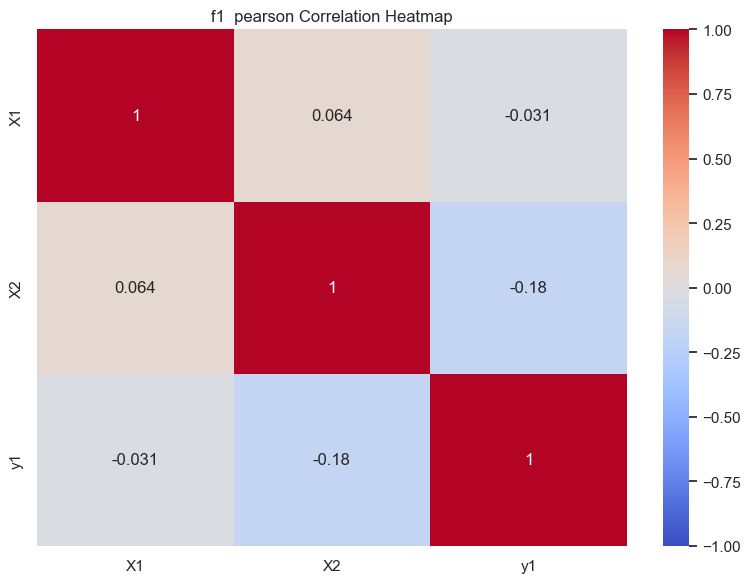


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.164550,0.423573
X2,0.164550,1.000000,0.273001
y1,0.423573,0.273001,1.000000


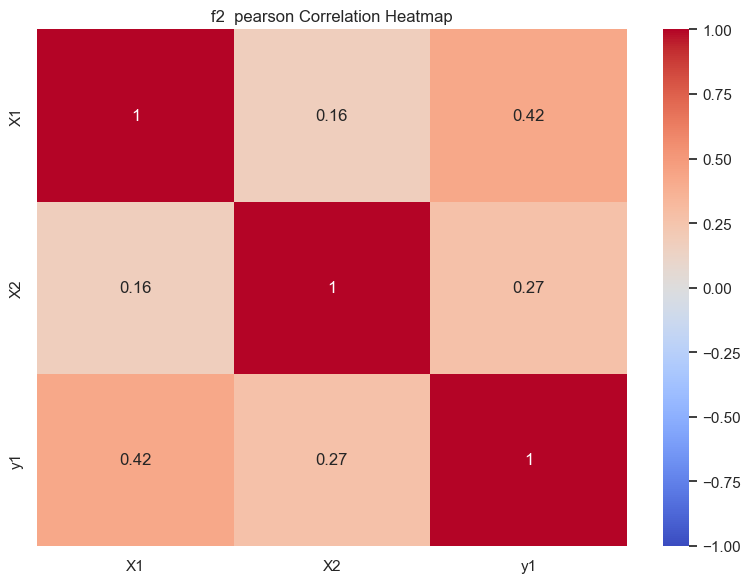


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.159138,0.071788,0.090311
X2,0.159138,1.000000,-0.266875,0.248325
X3,0.071788,-0.266875,1.000000,-0.408812
y1,0.090311,0.248325,-0.408812,1.000000


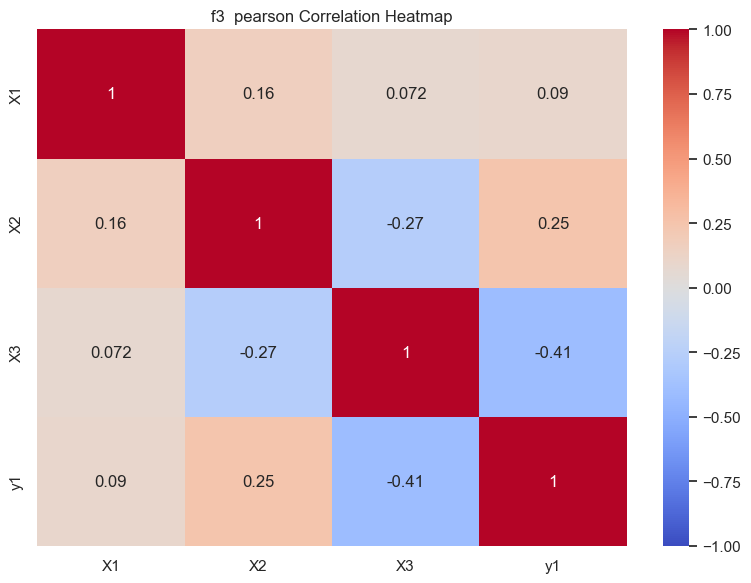


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.254674,0.265066,0.191544,-0.508344
X2,0.254674,1.000000,-0.064067,0.190325,-0.432131
X3,0.265066,-0.064067,1.000000,-0.147898,-0.148119
X4,0.191544,0.190325,-0.147898,1.000000,-0.427875
y1,-0.508344,-0.432131,-0.148119,-0.427875,1.000000


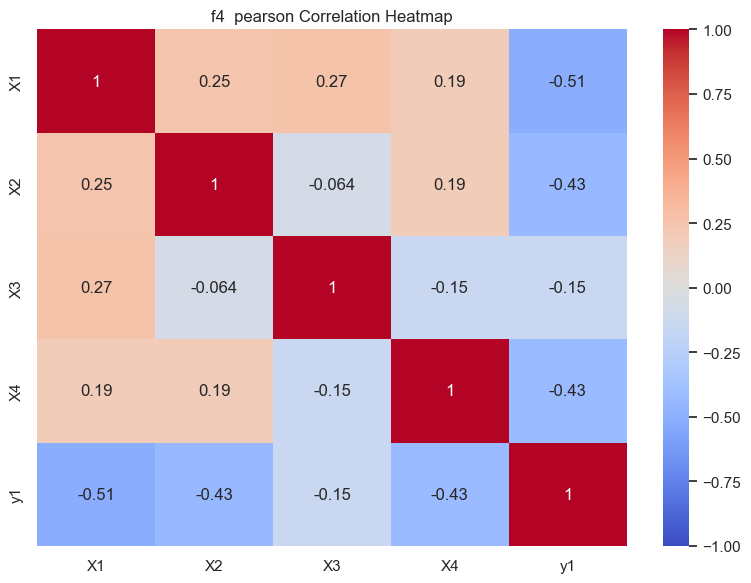


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.073189,-0.000176,0.216984,0.305037
X2,-0.073189,1.000000,0.192903,0.132628,0.459756
X3,-0.000176,0.192903,1.000000,-0.154341,0.531024
X4,0.216984,0.132628,-0.154341,1.000000,0.365977
y1,0.305037,0.459756,0.531024,0.365977,1.000000


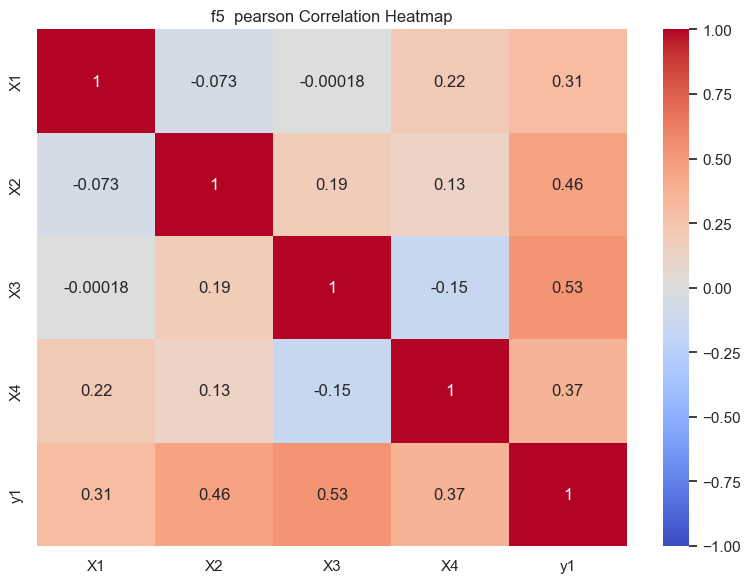


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.190809,-0.070881,0.131600,-0.366744,0.064622
X2,-0.190809,1.000000,0.150917,-0.199272,0.321563,-0.486164
X3,-0.070881,0.150917,1.000000,0.194723,-0.136822,0.281797
X4,0.131600,-0.199272,0.194723,1.000000,-0.322645,0.609744
X5,-0.366744,0.321563,-0.136822,-0.322645,1.000000,-0.634828
y1,0.064622,-0.486164,0.281797,0.609744,-0.634828,1.000000


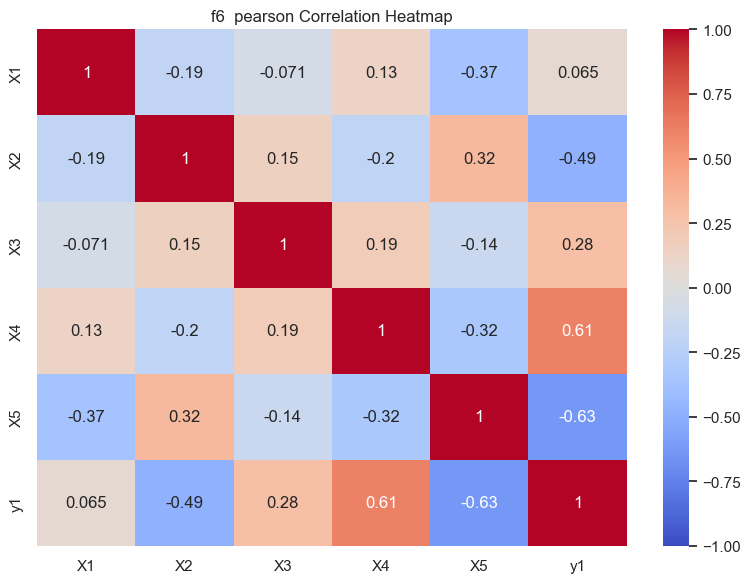


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.004209,-0.096325,-0.048612,0.027145,-0.486946,-0.457702
X2,0.004209,1.000000,0.106038,0.125948,0.314784,0.181014,-0.057866
X3,-0.096325,0.106038,1.000000,0.197859,-0.249496,0.067946,0.054835
X4,-0.048612,0.125948,0.197859,1.000000,0.069815,0.006066,-0.148005
X5,0.027145,0.314784,-0.249496,0.069815,1.000000,0.047300,-0.313410
X6,-0.486946,0.181014,0.067946,0.006066,0.047300,1.000000,0.365286
y1,-0.457702,-0.057866,0.054835,-0.148005,-0.313410,0.365286,1.000000


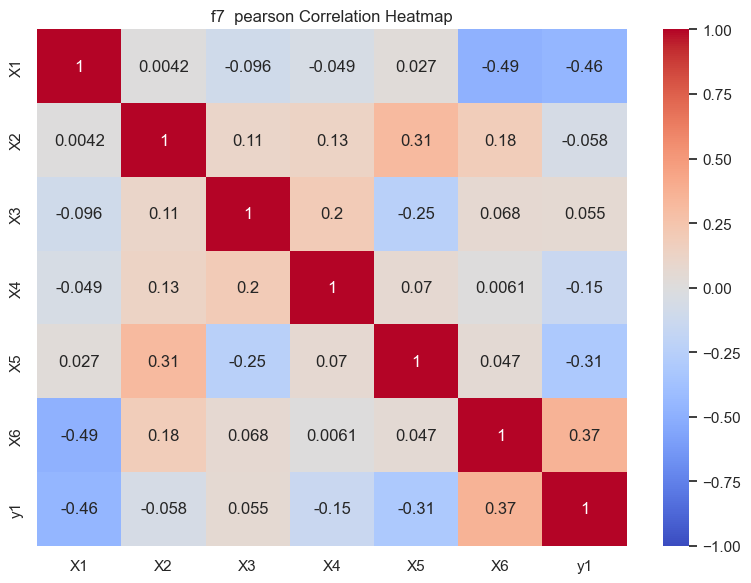


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.172718,0.109841,0.158529,0.216012,0.156634,0.215567,0.109481,-0.641557
X2,0.172718,1.000000,0.137278,-0.139760,0.033970,0.021216,-0.077289,-0.272650,-0.285767
X3,0.109841,0.137278,1.000000,0.125235,-0.102652,-0.183046,-0.046863,-0.017794,-0.681813
X4,0.158529,-0.139760,0.125235,1.000000,-0.084506,-0.103181,-0.000618,0.359102,-0.198288
X5,0.216012,0.033970,-0.102652,-0.084506,1.000000,0.071317,0.105165,0.086077,-0.038224
X6,0.156634,0.021216,-0.183046,-0.103181,0.071317,1.000000,-0.002839,0.053044,0.048277
X7,0.215567,-0.077289,-0.046863,-0.000618,0.105165,-0.002839,1.000000,-0.156250,-0.407502
X8,0.109481,-0.272650,-0.017794,0.359102,0.086077,0.053044,-0.156250,1.000000,0.081936
y1,-0.641557,-0.285767,-0.681813,-0.198288,-0.038224,0.048277,-0.407502,0.081936,1.000000


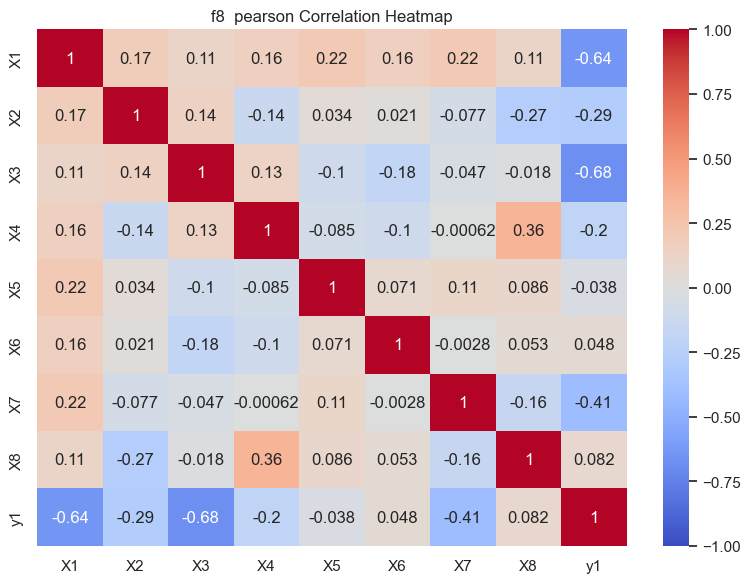

In [92]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.232143,0.196429
X2,-0.232143,1.000000,0.646429
y1,0.196429,0.646429,1.000000


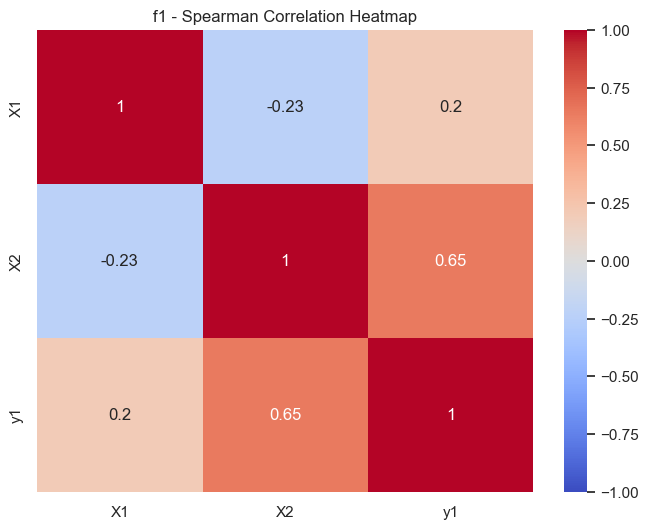


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.092857,0.360714
X2,0.092857,1.000000,0.278571
y1,0.360714,0.278571,1.000000


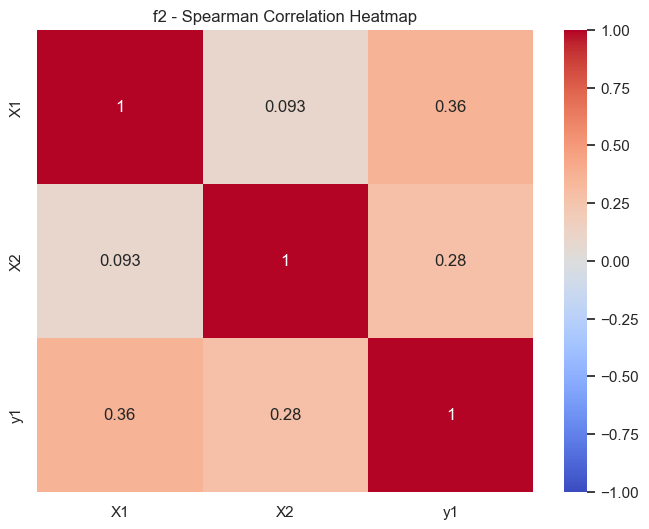


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.213534,-0.037594,-0.012030
X2,0.213534,1.000000,-0.267669,0.303759
X3,-0.037594,-0.267669,1.000000,-0.156391
y1,-0.012030,0.303759,-0.156391,1.000000


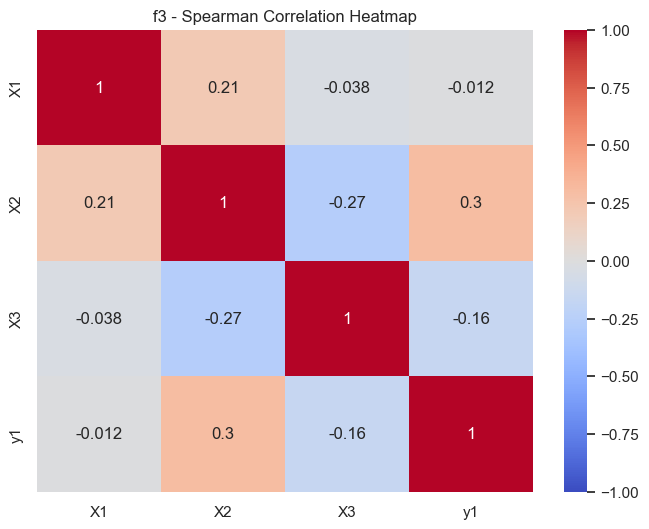


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.264986,0.260504,0.194118,-0.511485
X2,0.264986,1.000000,-0.008683,0.171989,-0.444818
X3,0.260504,-0.008683,1.000000,-0.178151,-0.171989
X4,0.194118,0.171989,-0.178151,1.000000,-0.382633
y1,-0.511485,-0.444818,-0.171989,-0.382633,1.000000


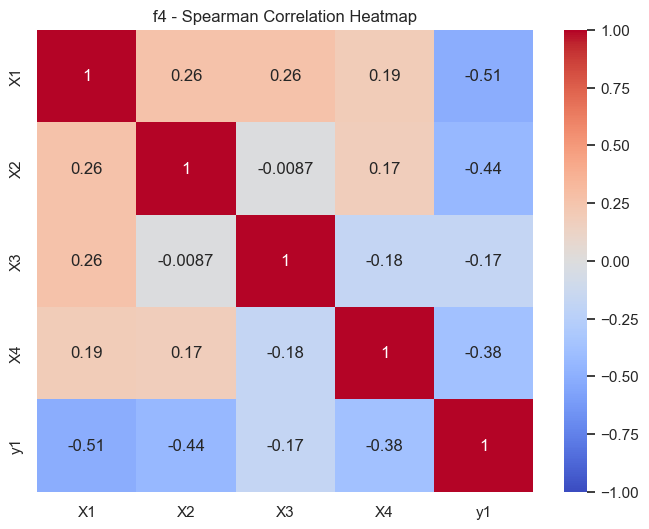


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.122308,-0.012308,0.176923,0.022308
X2,-0.122308,1.000000,0.262308,0.114615,0.415385
X3,-0.012308,0.262308,1.000000,-0.186154,0.533077
X4,0.176923,0.114615,-0.186154,1.000000,0.352308
y1,0.022308,0.415385,0.533077,0.352308,1.000000


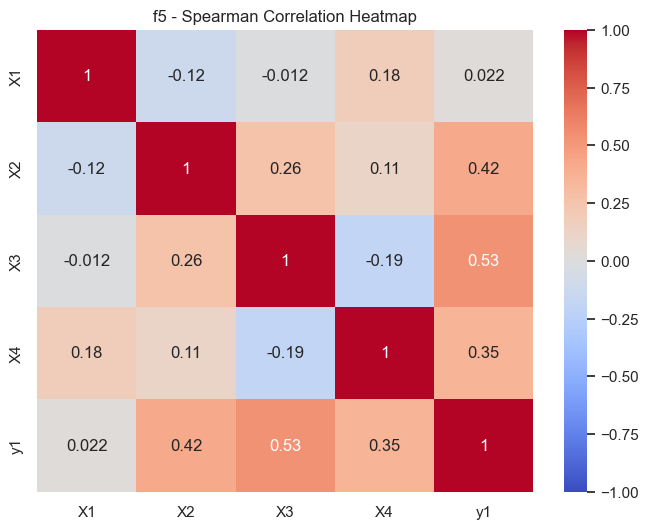


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.133513,-0.051943,0.147721,-0.347375,-0.038469
X2,-0.133513,1.000000,0.066564,-0.184651,0.273514,-0.420081
X3,-0.051943,0.066564,1.000000,0.217734,-0.162724,0.263128
X4,0.147721,-0.184651,0.217734,1.000000,-0.386154,0.639231
X5,-0.347375,0.273514,-0.162724,-0.386154,1.000000,-0.615385
y1,-0.038469,-0.420081,0.263128,0.639231,-0.615385,1.000000


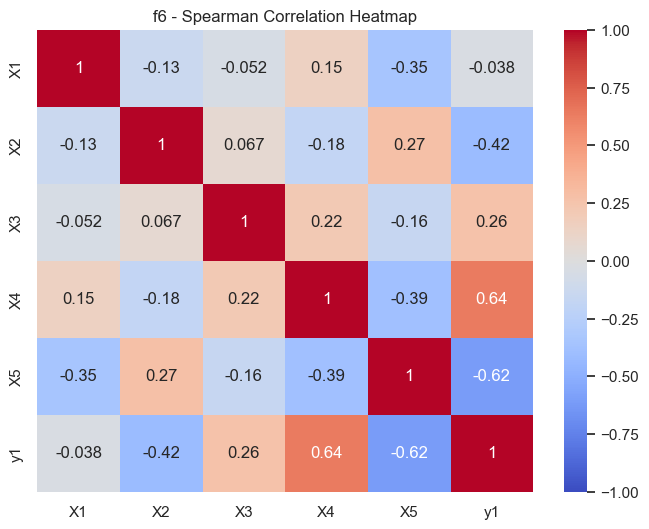


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.041176,-0.080112,-0.043697,-0.015966,-0.459664,-0.448179
X2,-0.041176,1.000000,0.078151,0.186835,0.333053,0.167787,-0.126891
X3,-0.080112,0.078151,1.000000,0.145938,-0.259664,0.113445,0.243697
X4,-0.043697,0.186835,0.145938,1.000000,0.066667,0.052661,-0.139496
X5,-0.015966,0.333053,-0.259664,0.066667,1.000000,0.031933,-0.428571
X6,-0.459664,0.167787,0.113445,0.052661,0.031933,1.000000,0.305322
y1,-0.448179,-0.126891,0.243697,-0.139496,-0.428571,0.305322,1.000000


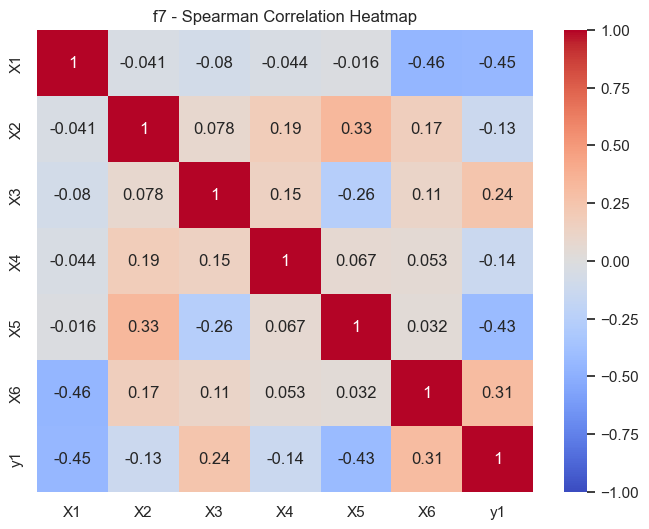


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.183939,0.089500,0.156454,0.215511,0.154058,0.197604,0.098242,-0.626638
X2,0.183939,1.000000,0.165545,-0.146804,0.006272,-0.010783,-0.074351,-0.263514,-0.295923
X3,0.089500,0.165545,1.000000,0.166673,-0.116917,-0.158497,-0.027625,-0.062934,-0.642001
X4,0.156454,-0.146804,0.166673,1.000000,-0.099584,-0.132708,0.006131,0.340334,-0.206420
X5,0.215511,0.006272,-0.116917,-0.099584,1.000000,0.111706,0.113535,0.048982,-0.005849
X6,0.154058,-0.010783,-0.158497,-0.132708,0.111706,1.000000,0.017266,0.096342,0.012615
X7,0.197604,-0.074351,-0.027625,0.006131,0.113535,0.017266,1.000000,-0.152014,-0.398027
X8,0.098242,-0.263514,-0.062934,0.340334,0.048982,0.096342,-0.152014,1.000000,0.080271
y1,-0.626638,-0.295923,-0.642001,-0.206420,-0.005849,0.012615,-0.398027,0.080271,1.000000


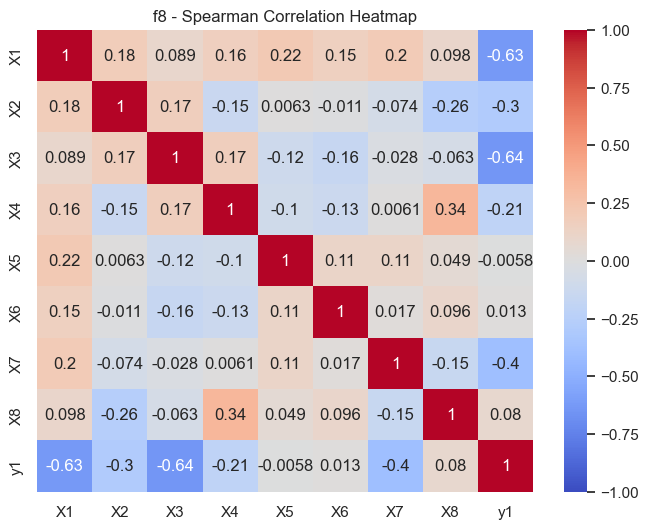

In [93]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.180952,0.123810
X2,-0.180952,1.000000,0.466667
y1,0.123810,0.466667,1.000000


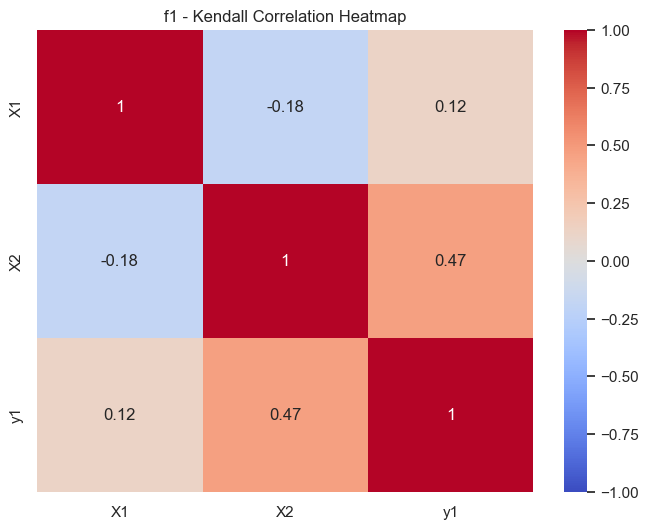


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.066667,0.238095
X2,0.066667,1.000000,0.219048
y1,0.238095,0.219048,1.000000


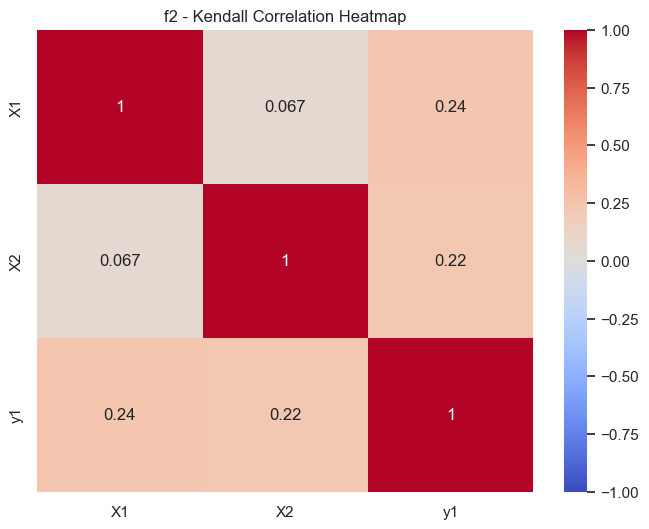


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.168421,-0.031579,0.010526
X2,0.168421,1.000000,-0.210526,0.231579
X3,-0.031579,-0.210526,1.000000,-0.073684
y1,0.010526,0.231579,-0.073684,1.000000


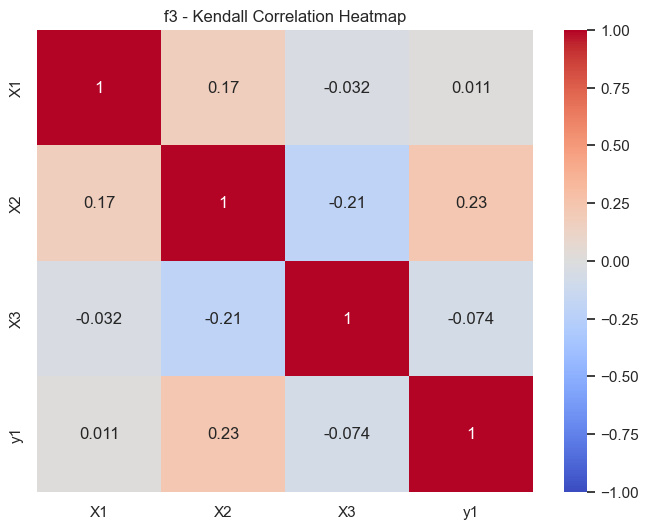


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.183193,0.203361,0.132773,-0.347899
X2,0.183193,1.000000,0.011765,0.129412,-0.310924
X3,0.203361,0.011765,1.000000,-0.139496,-0.163025
X4,0.132773,0.129412,-0.139496,1.000000,-0.267227
y1,-0.347899,-0.310924,-0.163025,-0.267227,1.000000


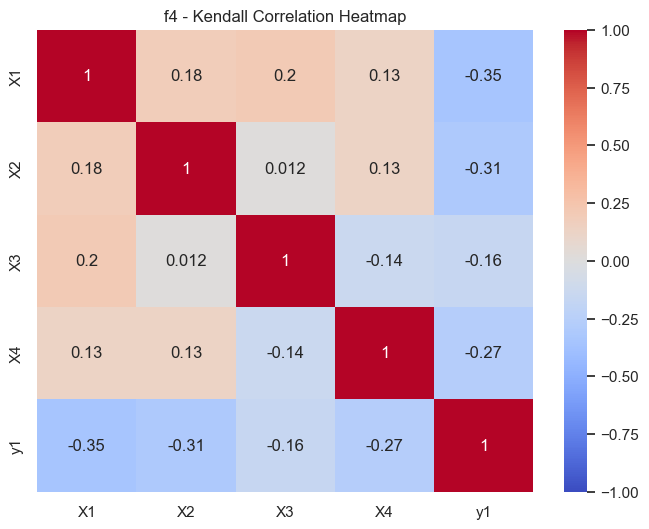


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.093333,-0.020000,0.146667,-0.020000
X2,-0.093333,1.000000,0.153333,0.053333,0.273333
X3,-0.020000,0.153333,1.000000,-0.153333,0.400000
X4,0.146667,0.053333,-0.153333,1.000000,0.233333
y1,-0.020000,0.273333,0.400000,0.233333,1.000000


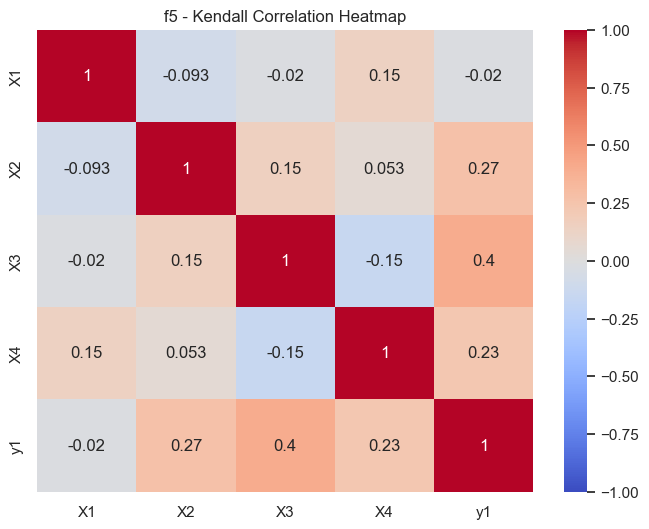


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.103679,-0.023411,0.123539,-0.277129,-0.023372
X2,-0.103679,1.000000,0.050167,-0.123539,0.170284,-0.310518
X3,-0.023411,0.050167,1.000000,0.156928,-0.083473,0.183640
X4,0.123539,-0.123539,0.156928,1.000000,-0.313333,0.466667
X5,-0.277129,0.170284,-0.083473,-0.313333,1.000000,-0.433333
y1,-0.023372,-0.310518,0.183640,0.466667,-0.433333,1.000000


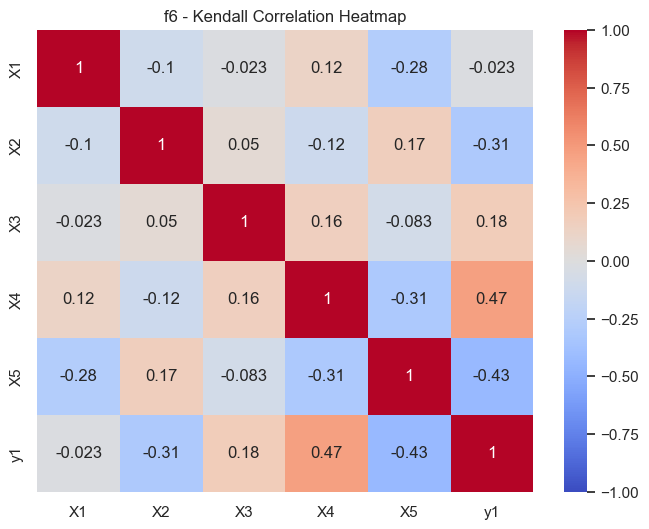


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.008403,-0.052101,-0.031933,-0.028571,-0.321008,-0.351261
X2,-0.008403,1.000000,0.048739,0.122689,0.226891,0.089076,-0.095798
X3,-0.052101,0.048739,1.000000,0.078992,-0.173109,0.092437,0.156303
X4,-0.031933,0.122689,0.078992,1.000000,0.048739,0.025210,-0.105882
X5,-0.028571,0.226891,-0.173109,0.048739,1.000000,0.042017,-0.284034
X6,-0.321008,0.089076,0.092437,0.025210,0.042017,1.000000,0.203361
y1,-0.351261,-0.095798,0.156303,-0.105882,-0.284034,0.203361,1.000000


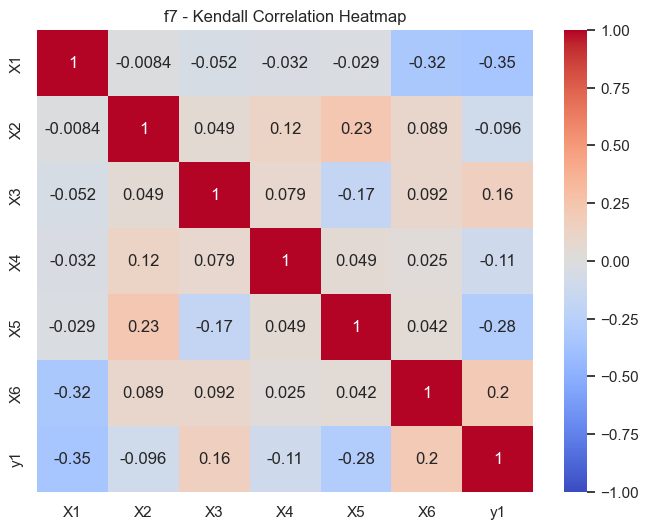


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.138551,0.031712,0.094130,0.142782,0.081438,0.116279,0.064516,-0.450317
X2,0.138551,1.000000,0.098361,-0.111111,0.017989,-0.039153,-0.062401,-0.166138,-0.176626
X3,0.031712,0.098361,1.000000,0.092015,-0.075093,-0.111052,-0.014799,-0.043363,-0.471459
X4,0.094130,-0.111111,0.092015,1.000000,-0.060317,-0.062434,0.007403,0.242328,-0.136436
X5,0.142782,0.017989,-0.075093,-0.060317,1.000000,0.079365,0.077208,0.041270,0.009519
X6,0.081438,-0.039153,-0.111052,-0.062434,0.079365,1.000000,0.020095,0.060317,-0.005288
X7,0.116279,-0.062401,-0.014799,0.007403,0.077208,0.020095,1.000000,-0.102591,-0.302326
X8,0.064516,-0.166138,-0.043363,0.242328,0.041270,0.060317,-0.102591,1.000000,0.058170
y1,-0.450317,-0.176626,-0.471459,-0.136436,0.009519,-0.005288,-0.302326,0.058170,1.000000


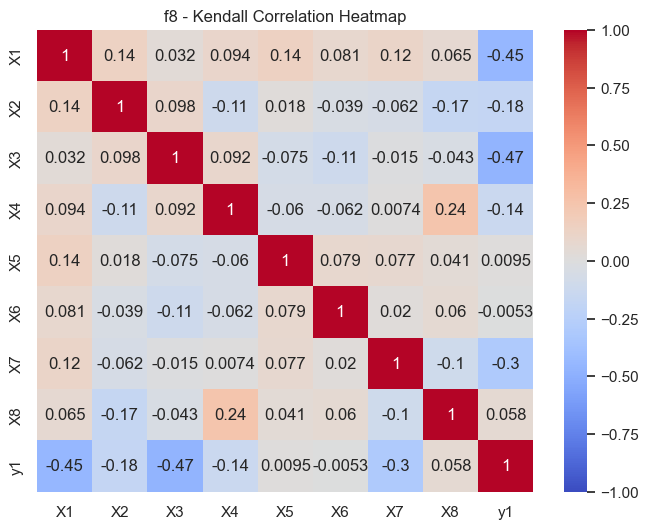

In [94]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [95]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.022222
1,X2,0.000000



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.462382
1,X2,0.000000



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.188402
3,X4,0.159066
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.125783
0,X1,0.092755
5,X6,0.086910
1,X2,0.004397
2,X3,0.000000
3,X4,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.359435
0,X1,0.294718
6,X7,0.143467
1,X2,0.016070
3,X4,0.004608
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Partial Correlation

In [97]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  15 -0.019756  [-0.54, 0.52]  0.946555
          n         r          CI95%     p-val
pearson  15 -0.177044  [-0.65, 0.39]  0.544852

f2 — Partial Correlation
          n         r          CI95%     p-val
pearson  15  0.399041  [-0.17, 0.77]  0.157537
          n         r          CI95%     p-val
pearson  15  0.227531  [-0.34, 0.68]  0.434031

f3 — Partial Correlation
          n         r          CI95%     p-val
pearson  20  0.105224  [-0.38, 0.55]  0.677751
          n         r          CI95%     p-val
pearson  20  0.137469  [-0.35, 0.57]  0.586472
          n         r          CI95%     p-val
pearson  20 -0.376556  [-0.72, 0.11]  0.123503

f4 — Partial Correlation
          n         r           CI95%     p-val
pearson  35 -0.383811  [-0.65, -0.04]  0.030113
          n         r          CI95%     p-val
pearson  35 -0.352045  [-0.62, -0.0]  0.048154
          n         r         CI95%     p-val
pe

#### Feature vs Output Plots 


Feature vs Output Plots for f1
X shape for f1: (15, 2)
y shape for f1: (15,)


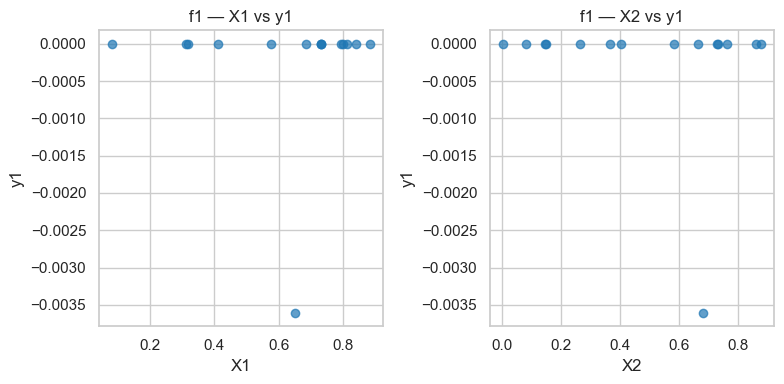


Feature vs Output Plots for f2
X shape for f2: (15, 2)
y shape for f2: (15,)


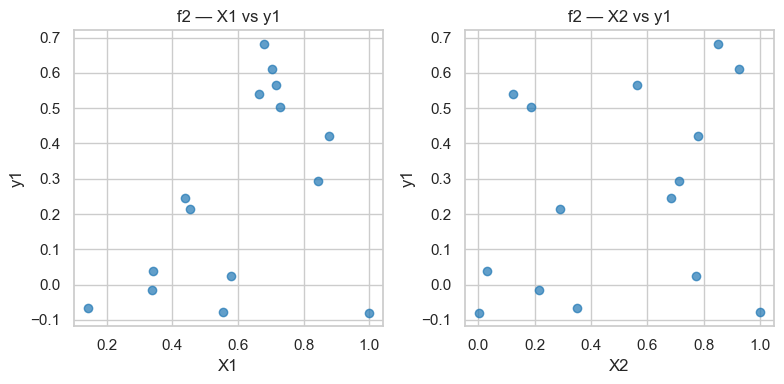


Feature vs Output Plots for f3
X shape for f3: (20, 3)
y shape for f3: (20,)


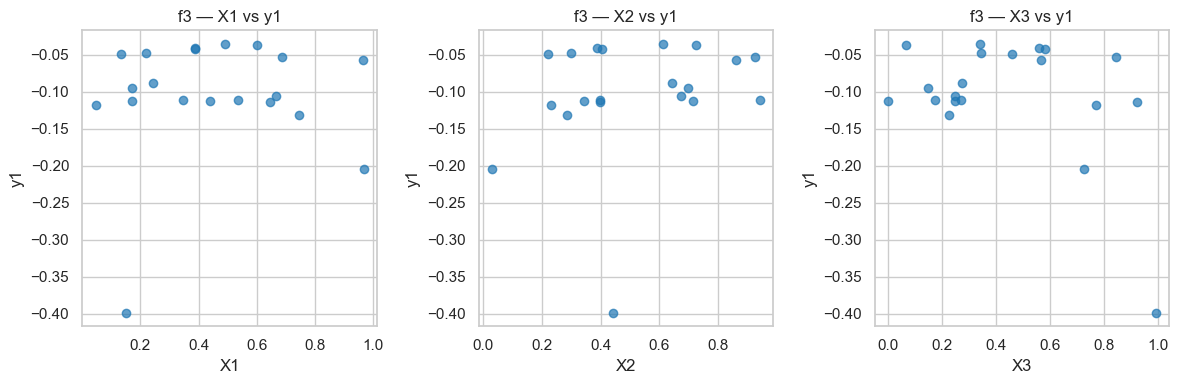


Feature vs Output Plots for f4
X shape for f4: (35, 4)
y shape for f4: (35,)


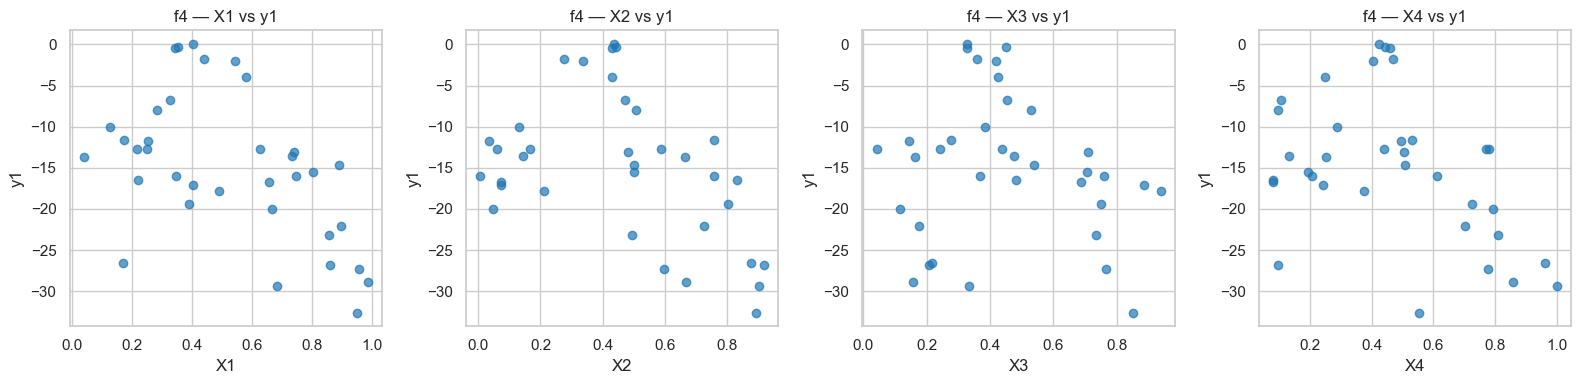


Feature vs Output Plots for f5
X shape for f5: (25, 4)
y shape for f5: (25,)


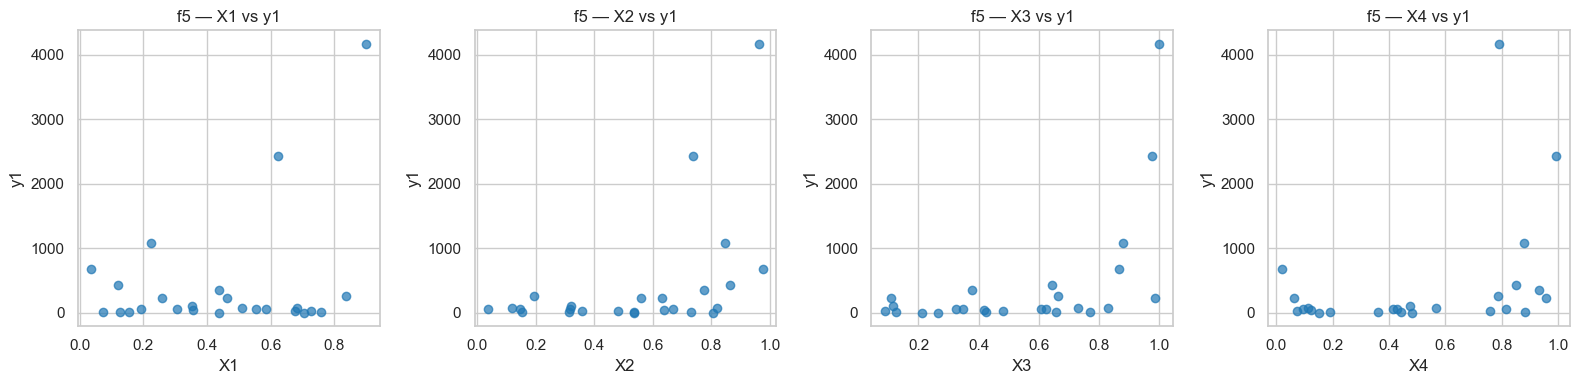


Feature vs Output Plots for f6
X shape for f6: (25, 5)
y shape for f6: (25,)


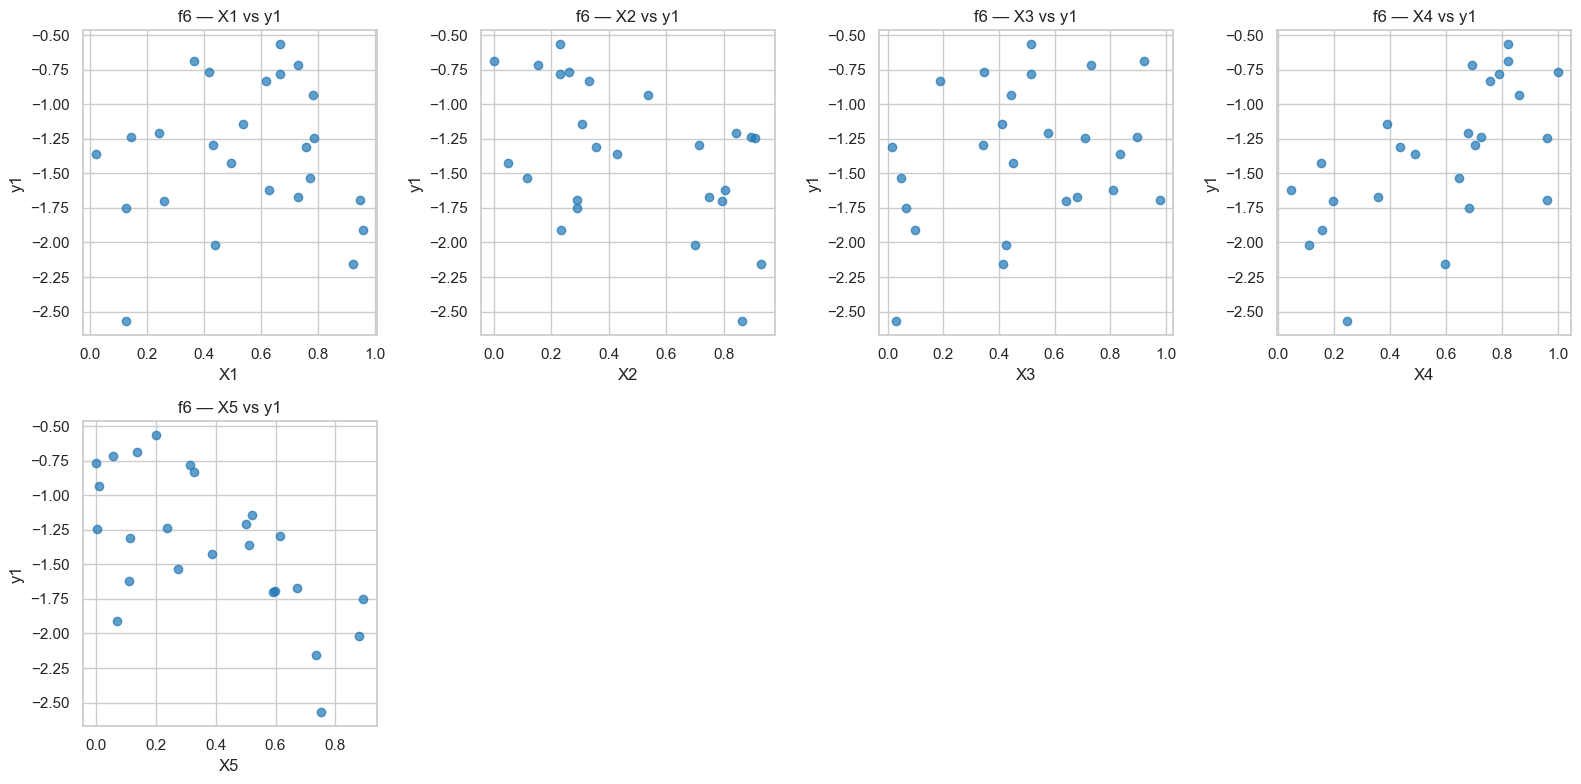


Feature vs Output Plots for f7
X shape for f7: (35, 6)
y shape for f7: (35,)


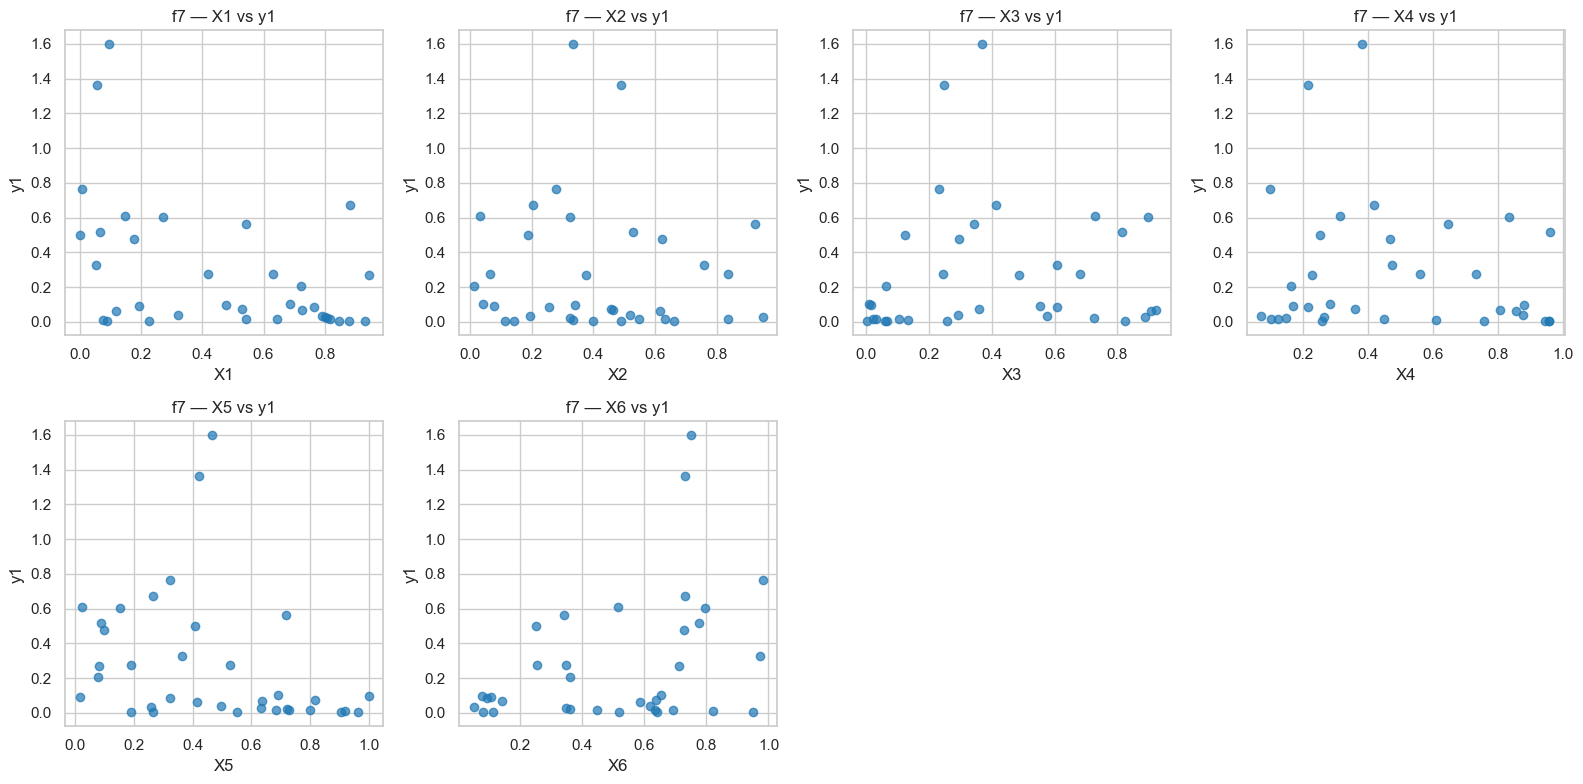


Feature vs Output Plots for f8
X shape for f8: (44, 8)
y shape for f8: (44,)


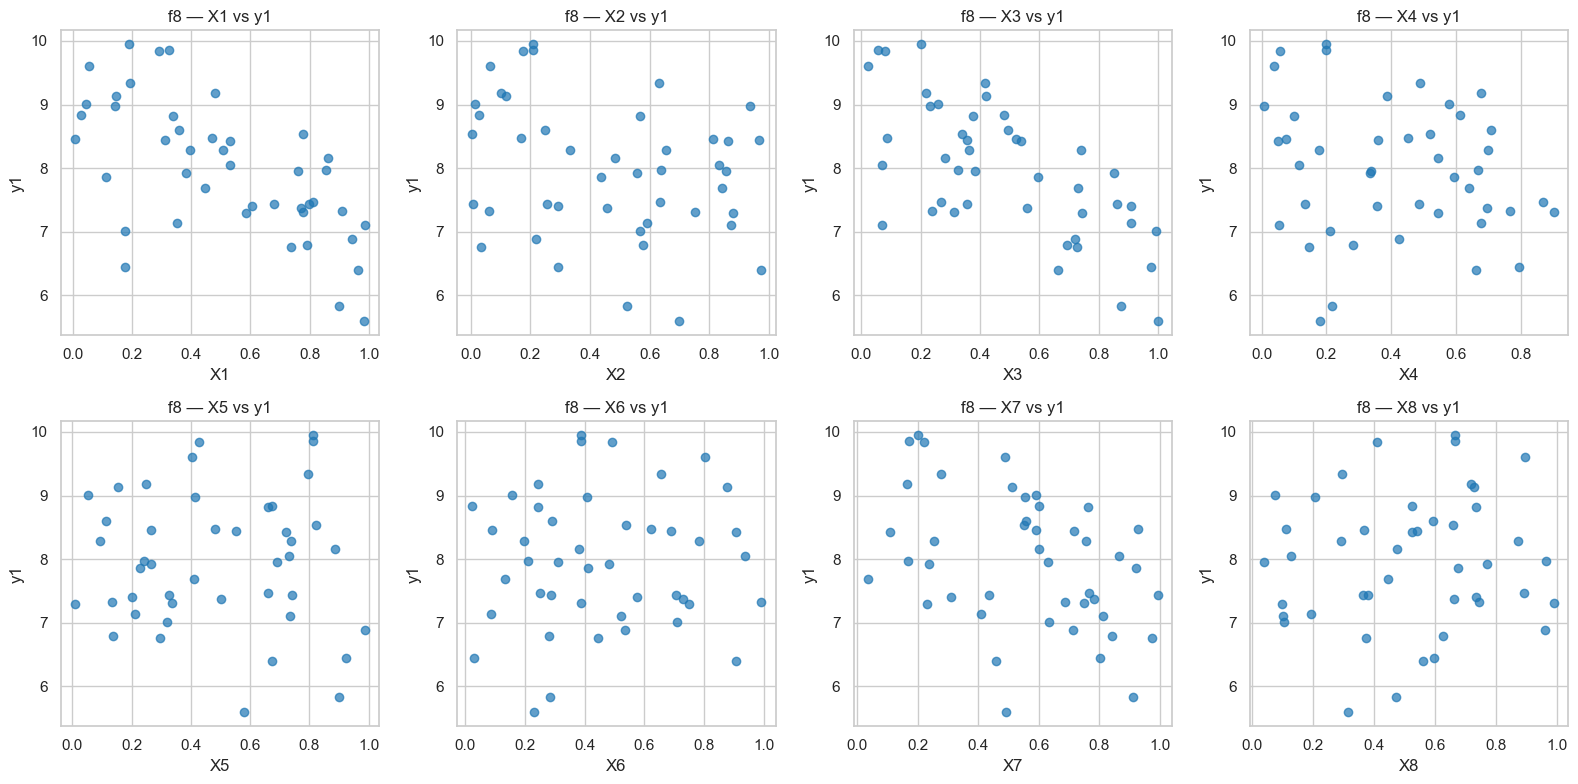

In [98]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")


    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot


    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"

    
    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


#### Distribution Analysis


f1 — Feature & Output Distributions


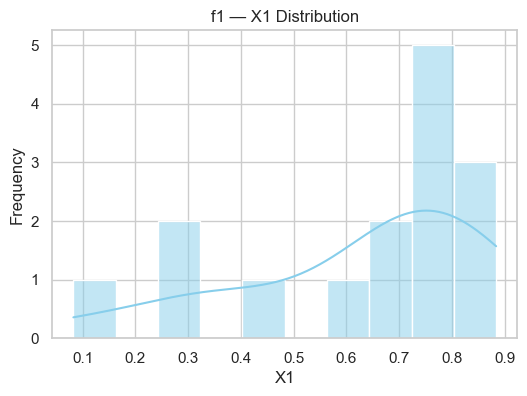

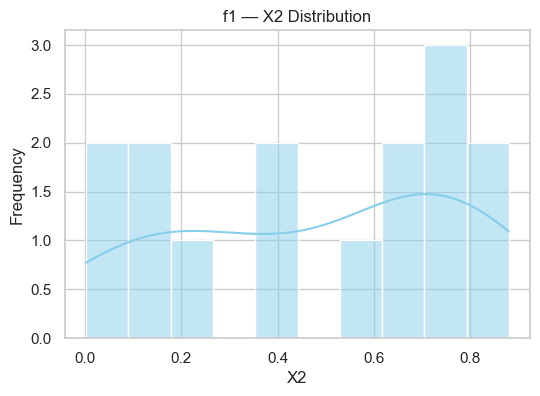

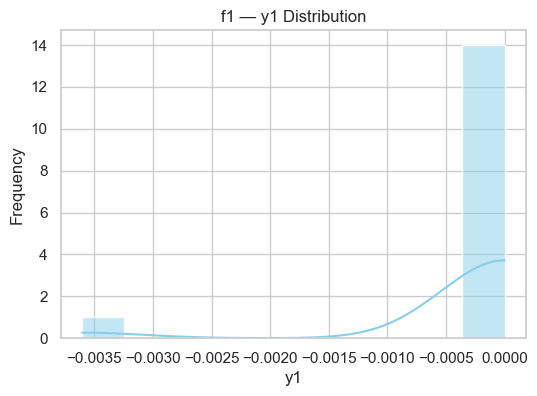


f2 — Feature & Output Distributions


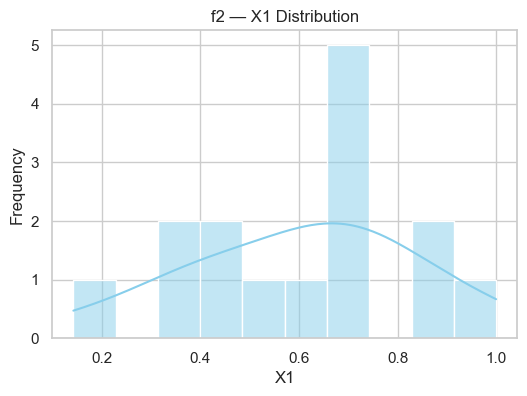

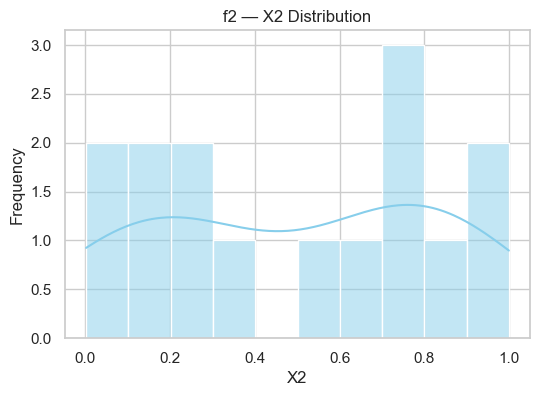

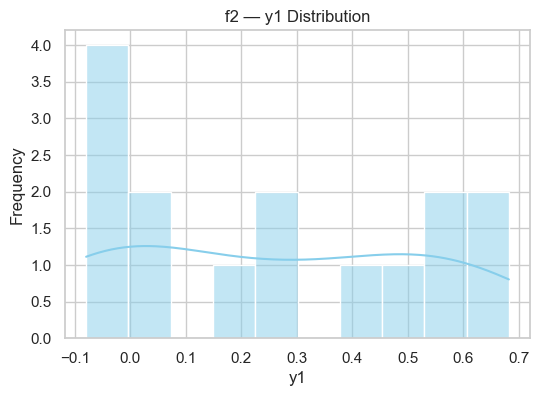


f3 — Feature & Output Distributions


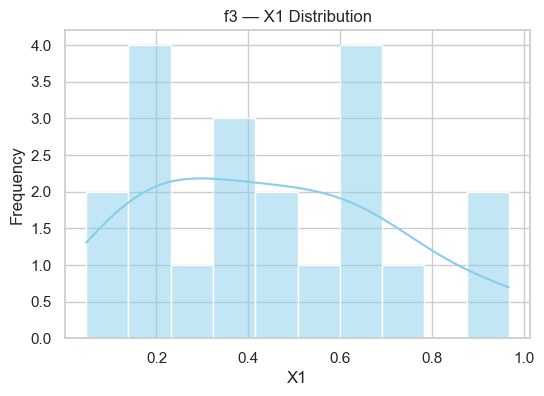

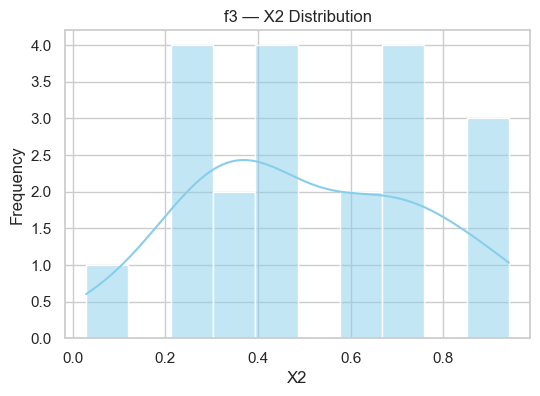

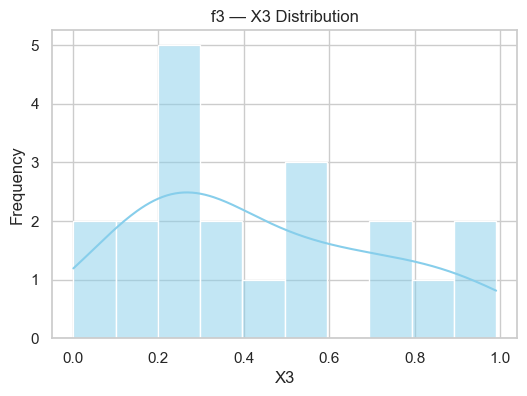

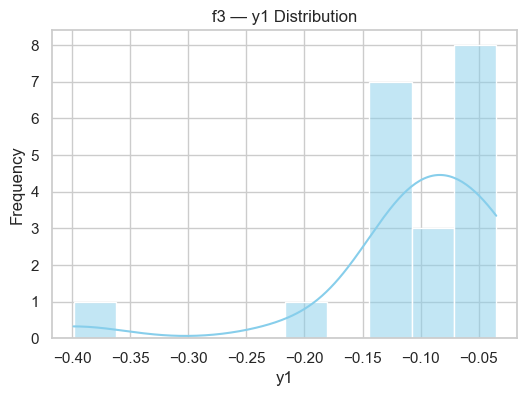


f4 — Feature & Output Distributions


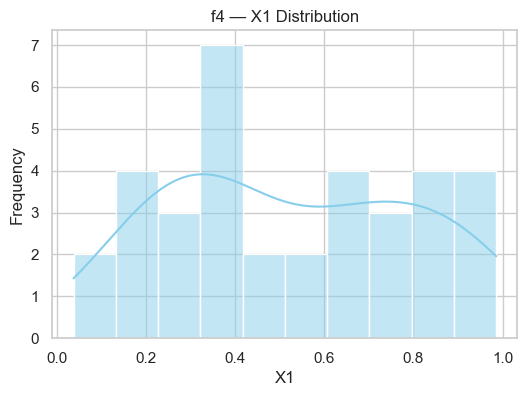

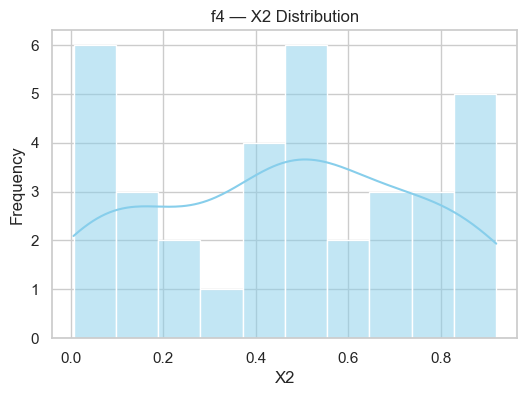

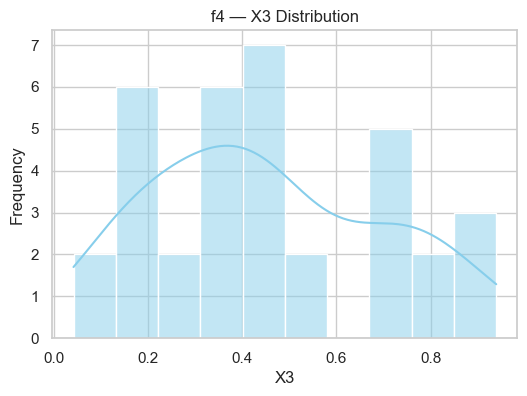

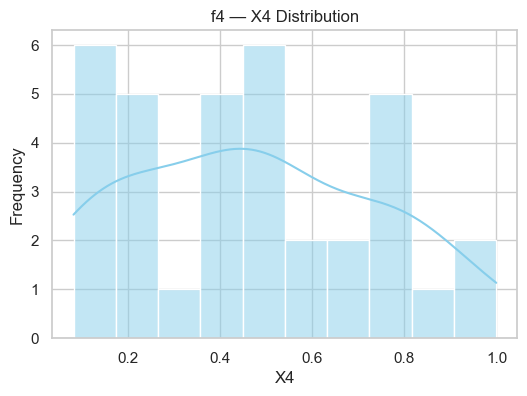

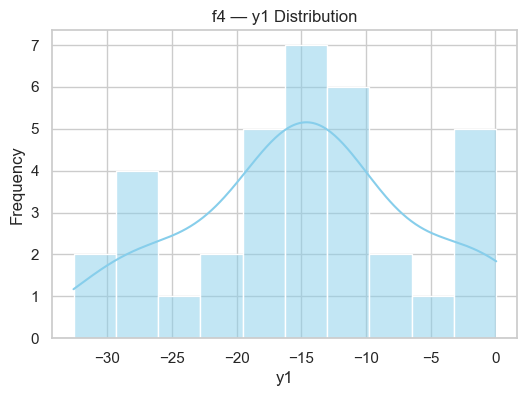


f5 — Feature & Output Distributions


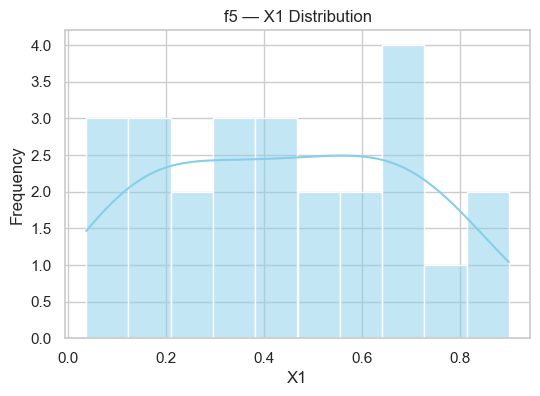

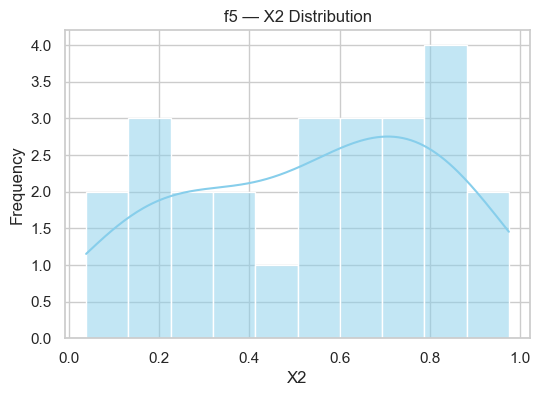

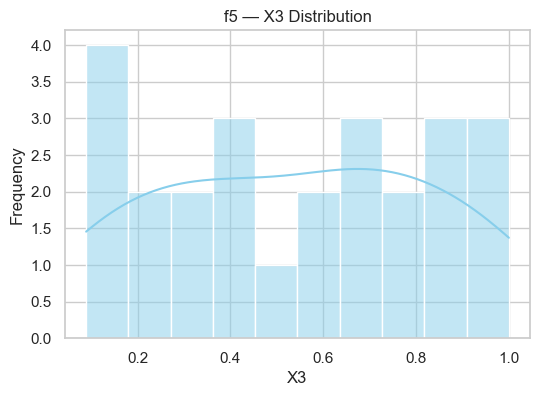

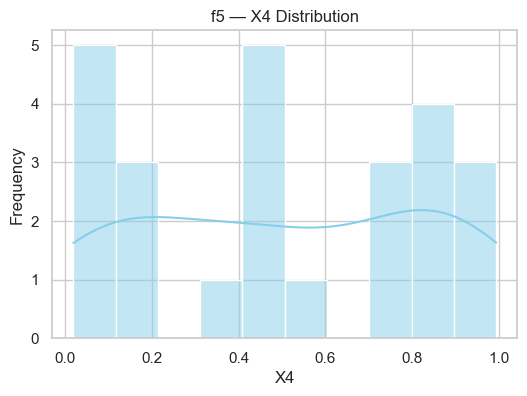

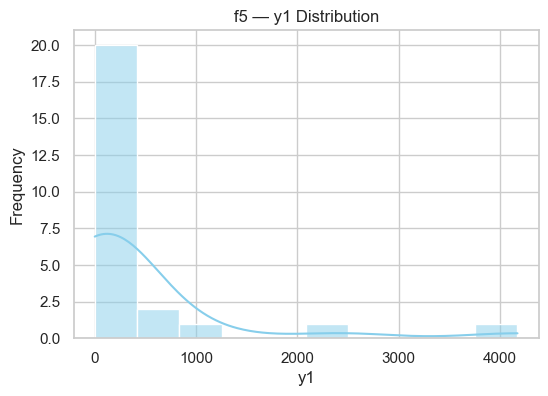


f6 — Feature & Output Distributions


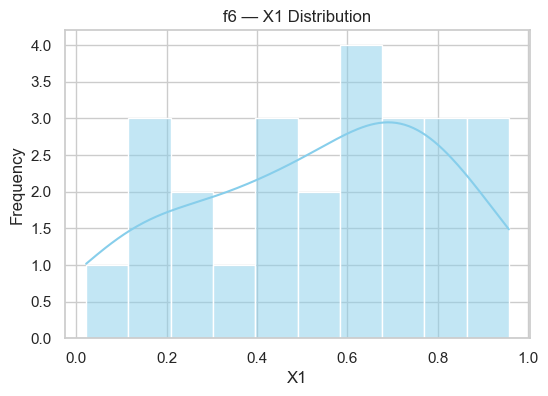

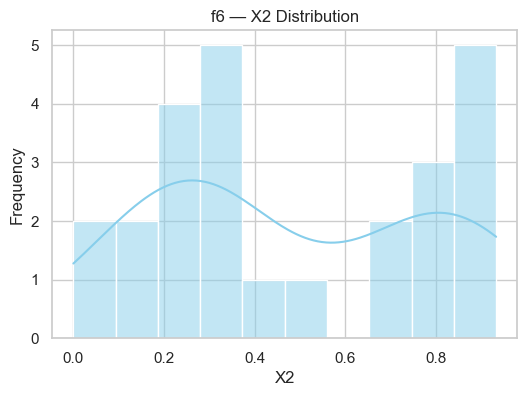

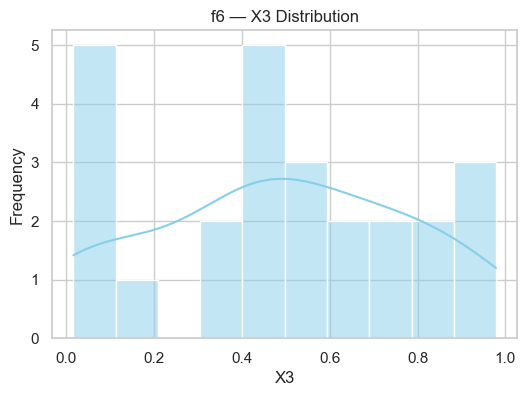

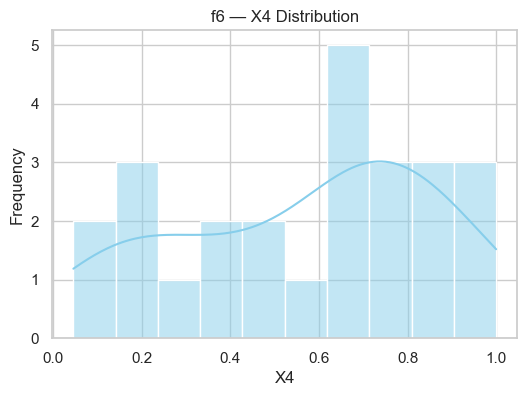

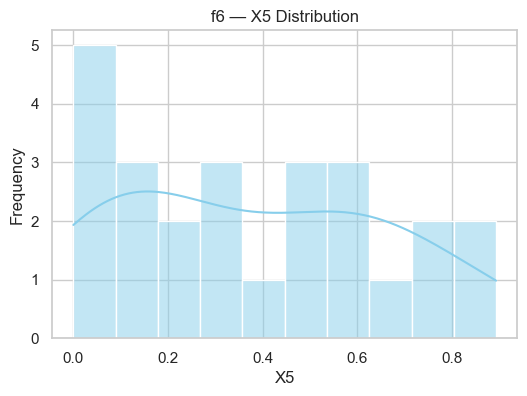

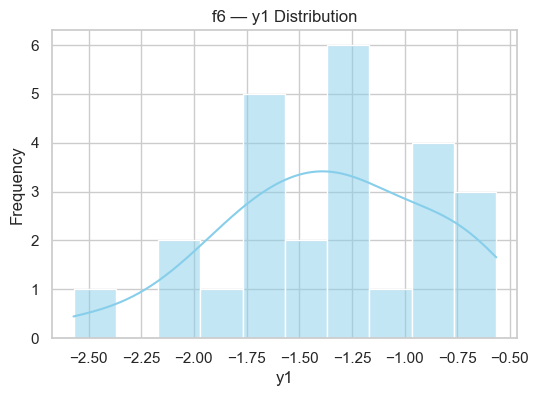


f7 — Feature & Output Distributions


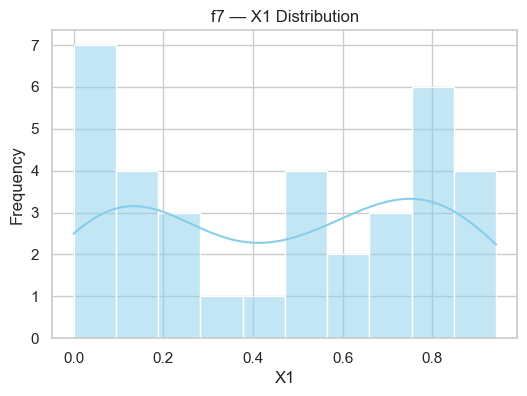

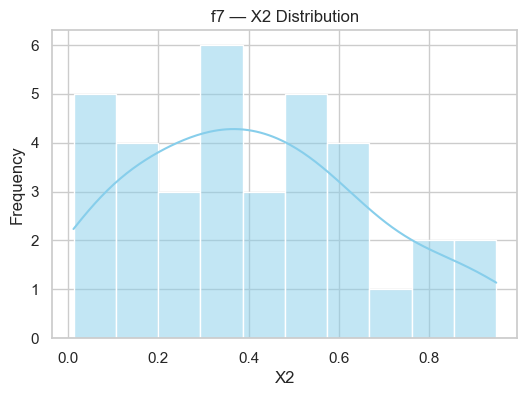

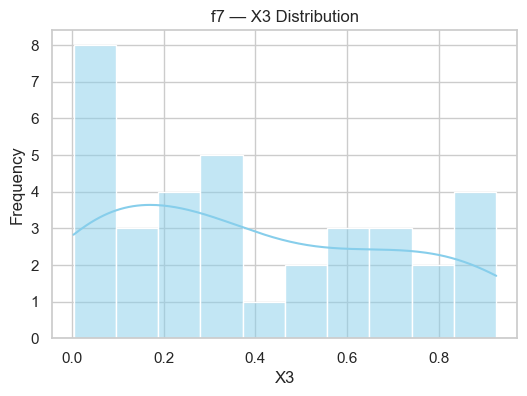

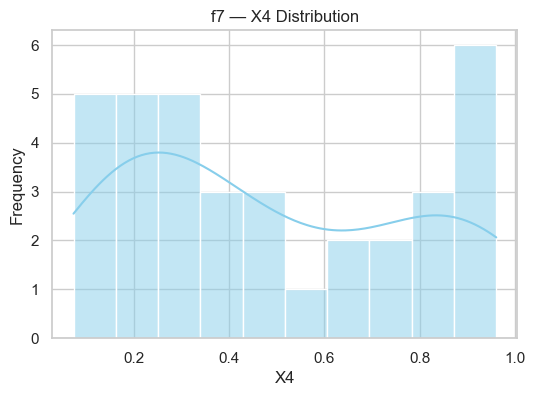

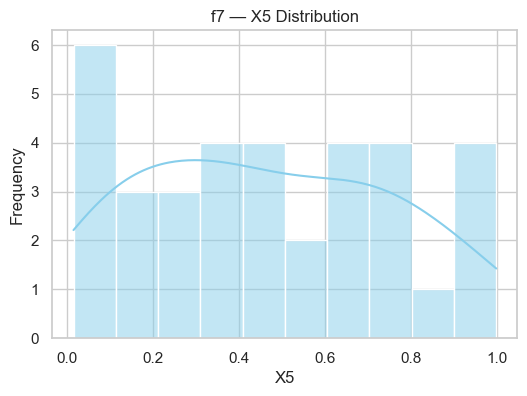

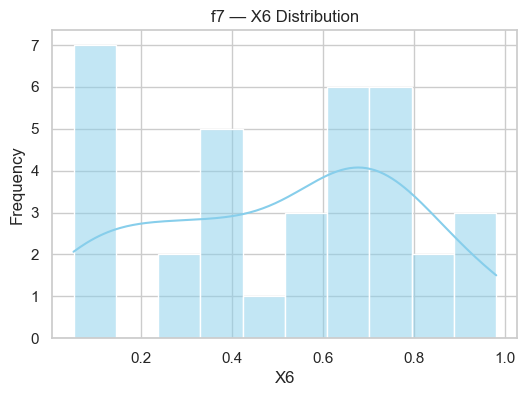

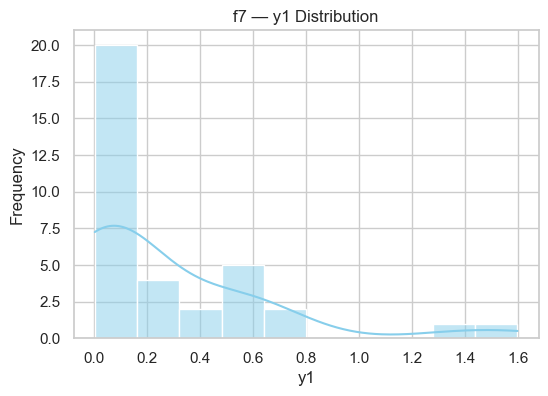


f8 — Feature & Output Distributions


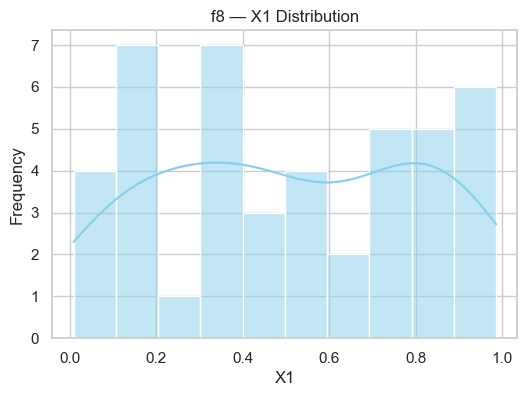

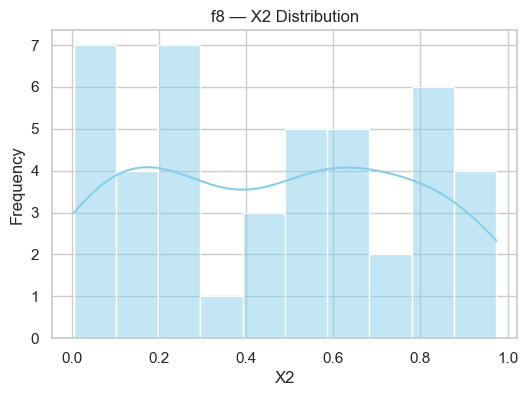

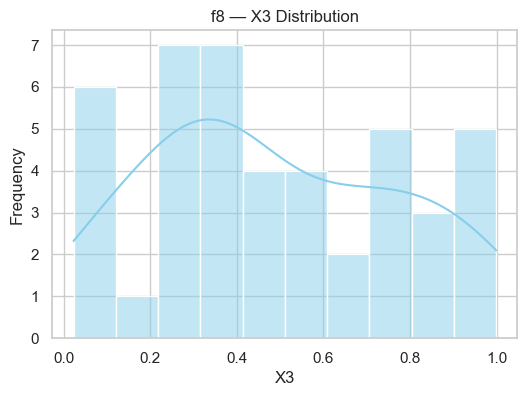

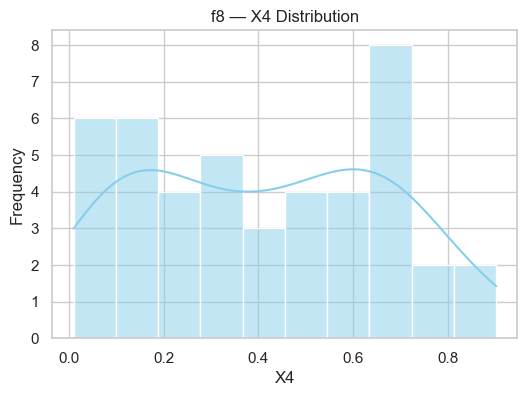

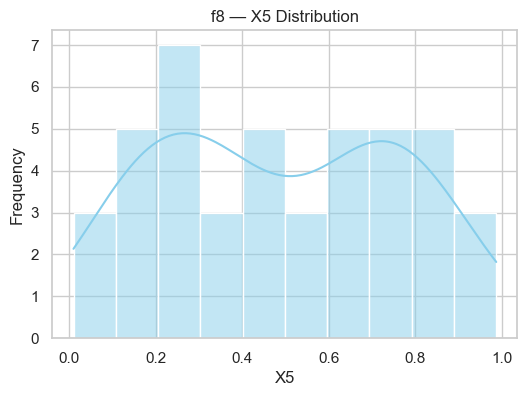

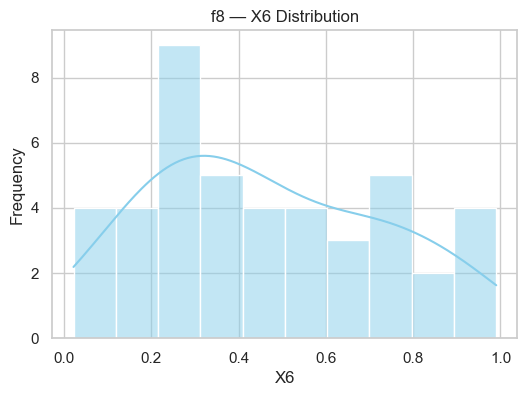

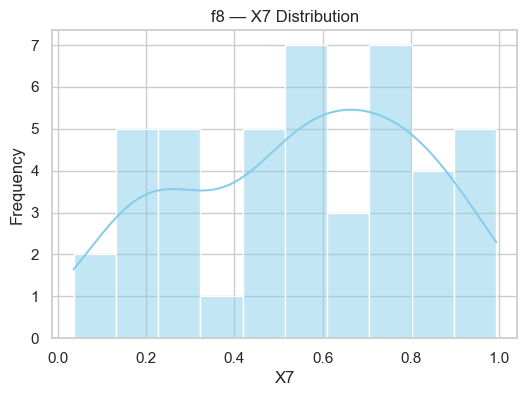

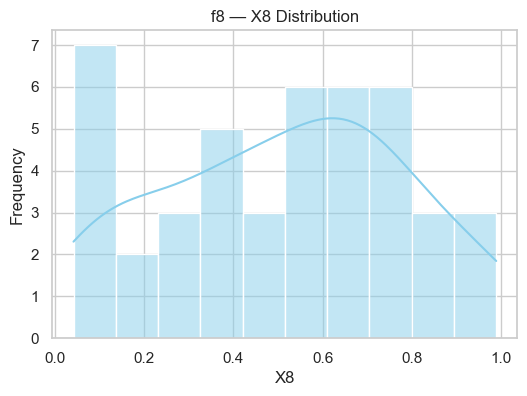

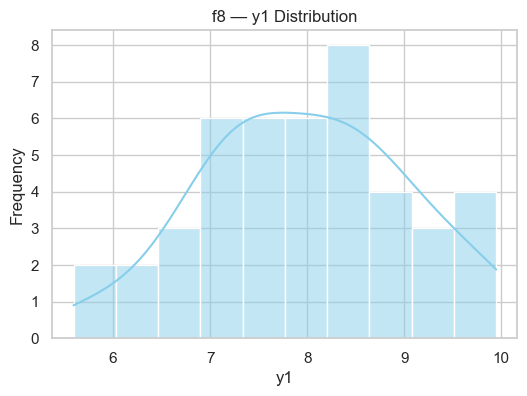

In [99]:
for name, df in functions_data.items():
    print(f"\n{name} — Feature & Output Distributions")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
13  0.732162  0.364472   5.473776e-57
14  0.812650  0.143347 -1.062933e-161

f1 — y vs Instance Plot


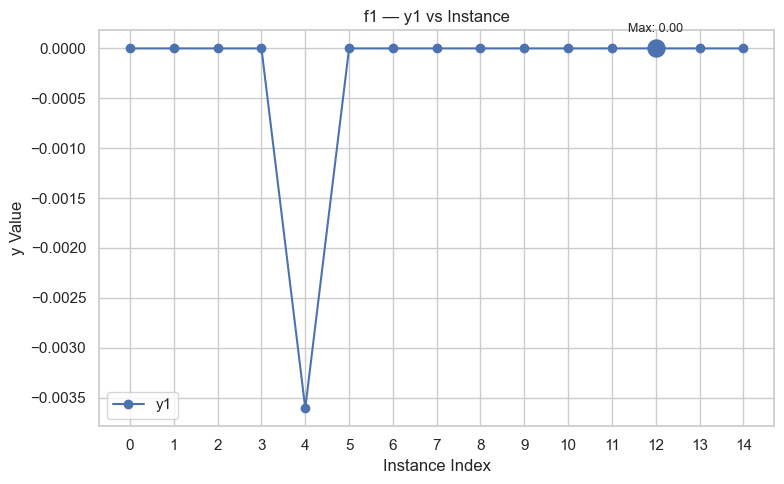


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
13  0.715483  0.563901  0.566166
14  0.678746  0.850809  0.682452

f2 — y vs Instance Plot


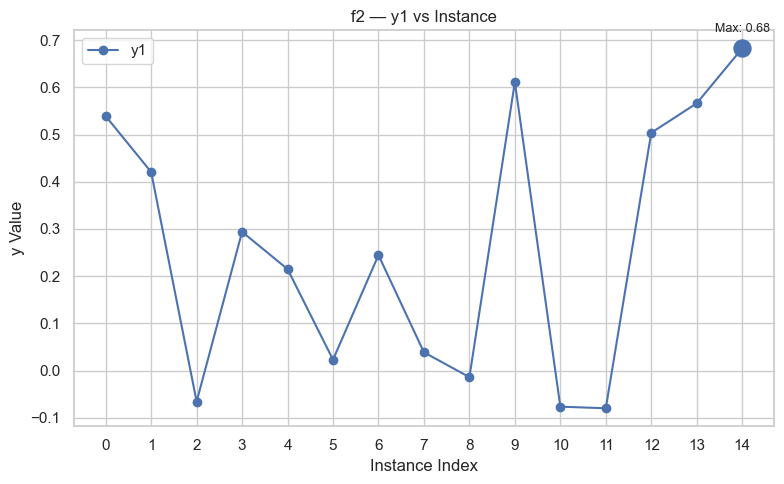


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768
18  0.387933  0.405240  0.580181 -0.041279
19  0.688252  0.924125  0.842251 -0.053147

f3 — y vs Instance Plot


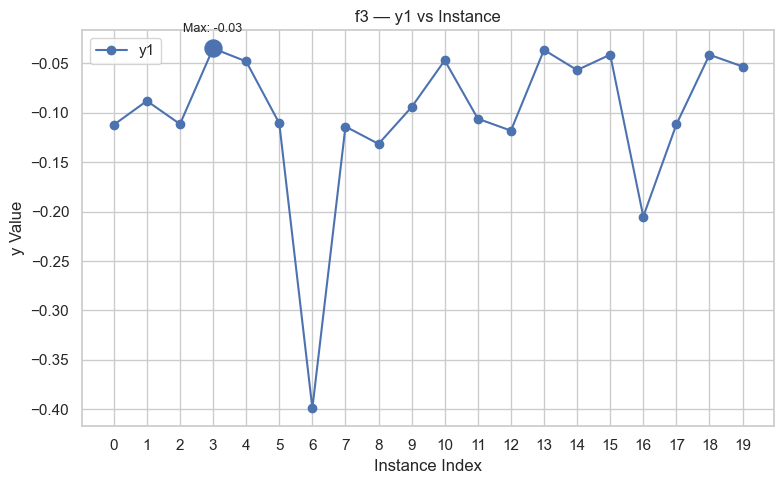


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

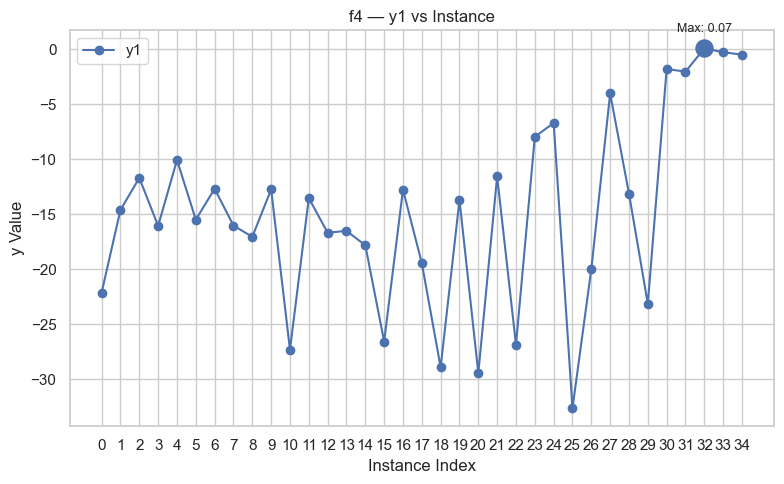


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

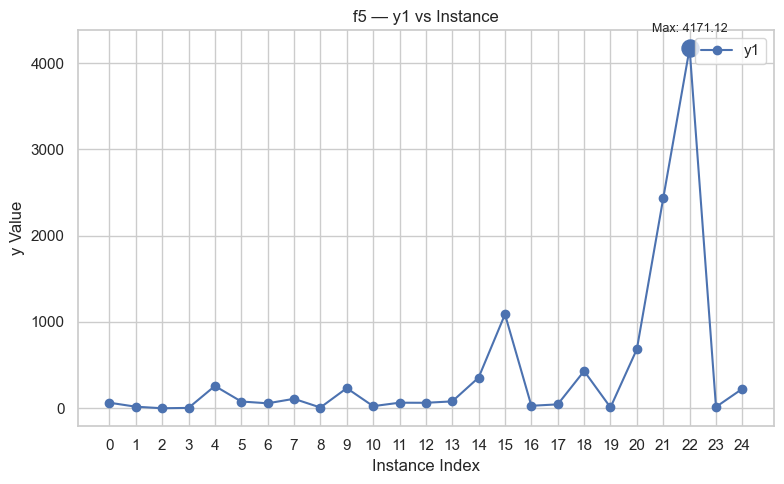


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

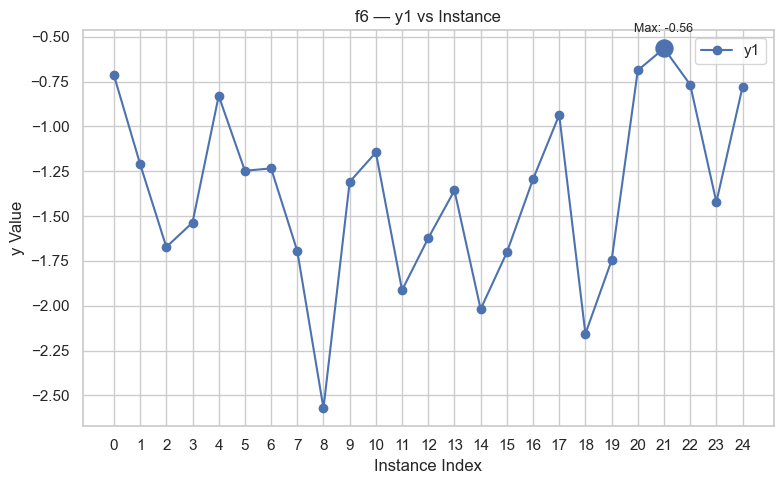


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

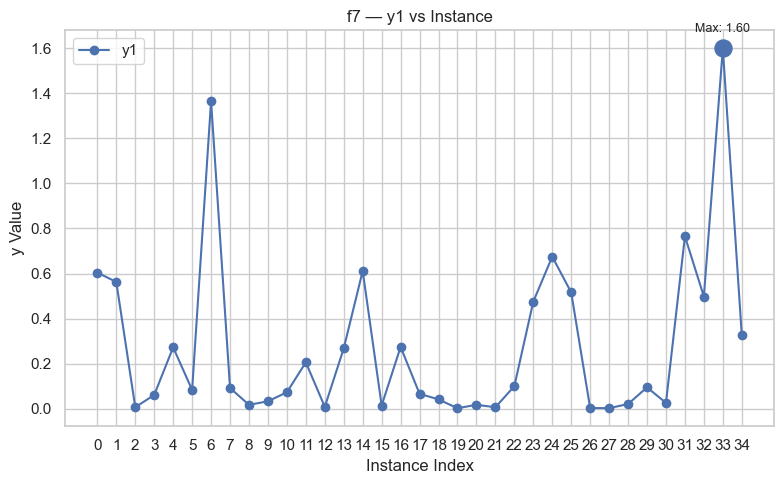


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

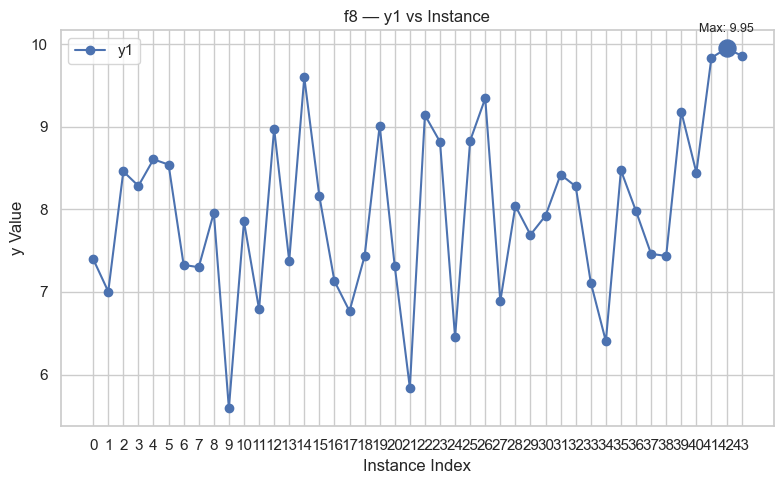

In [101]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | Spearman-Guided X2 Exploitation with Rank-Based Confirmation

In [102]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.stats.qmc import Sobol

In [103]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.3194038888 0.7629593743]
 [0.5743292145 0.879898105 ]
 [0.731023631  0.7329998764]
 [0.8403534169 0.264731614 ]
 [0.6501140598 0.6815263521]
 [0.4104371366 0.147554299 ]
 [0.3126911568 0.0787227779]
 [0.6834181689 0.8610574644]
 [0.0825072518 0.4034875064]
 [0.8838898288 0.5822539744]
 [0.7936       0.666269    ]
 [0.800601     0.0028      ]
 [0.729726     0.729276    ]
 [0.732162     0.364472    ]
 [0.81265      0.143347    ]]
[ 0.            0.            0.            0.           -0.0036060626
 -0.           -0.            0.            0.            0.
  0.            0.            0.            0.           -0.          ]


In [104]:
# this function proposes the next query point for f1
# it directly tests the spearman x2 signal by focusing on high x2 values
# it returns the predicted mean, standard deviation, and ucb value
# all comments are written in small letters for readability

def propose_f1_query(X_train_1, y_train_1):

    # step 1 fit the gaussian process surrogate
    kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-6)
    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        alpha=0.0
    )
    gp.fit(X_train_1, y_train_1)

    # step 2 generate sobol candidates
    sampler = Sobol(d=2, scramble=True)
    sobol_raw = sampler.random_base2(m=10)  # 1024 points
    X_cand = sobol_raw

    # apply x2 directional filter
    X_cand = X_cand[X_cand[:, 1] > 0.65]

    # step 3 apply diversity filter
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    survivors = np.array([x for x in X_cand if min_dist(x, X_train_1) > 0.10])

    # if too few survivors, relax threshold to 0.55
    if len(survivors) < 50:
        X_cand = sobol_raw[sobol_raw[:, 1] > 0.55]
        survivors = np.array([x for x in X_cand if min_dist(x, X_train_1) > 0.10])

    # fallback if still too few
    if len(survivors) == 0:
        survivors = sobol_raw

    # step 4 compute adaptive ucb
    # week 6 uses beta_t ≈ 1.79
    beta_start = 2.0
    beta_end = 0.1
    T = 50
    t = 6
    beta_t = beta_end + (beta_start - beta_end) * np.exp(-t / T)

    mu, sigma = gp.predict(survivors, return_std=True)
    ucb = mu + beta_t * sigma

    # select best candidate
    best_idx = np.argmax(ucb)
    next_x = survivors[best_idx]
    next_mean = mu[best_idx]
    next_std = sigma[best_idx]
    next_ucb = ucb[best_idx]

    return next_x, next_mean, next_std, next_ucb, gp
    
next_x, next_mean, next_std, next_ucb, gp = propose_f1_query(X_train_1, y_train_1)

print(f"Next Query for f1: {next_x}")
print(f"GP Mean: {next_mean}")
print(f"GP Std: {next_std}")
print(f"Predicted y: {next_ucb}")

Next Query for f1: [0.7213830743 0.9538077377]
GP Mean: -0.0002320134914204757
GP Std: 0.000898955783708777
Predicted y: 0.0013727563738755678


#### f2 | RBF‑whitekernel GP with asymmetric length scales and high‑beta UCB + Sobol Sequence

In [105]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[0.66579958   0.1239691277]
 [0.877790989  0.7786275008]
 [0.1426990742 0.3490051306]
 [0.8452754287 0.7111202666]
 [0.4546471411 0.2904551798]
 [0.5777128444 0.7719731841]
 [0.4381660616 0.6850182568]
 [0.341749593  0.0286977198]
 [0.3386481569 0.2138672456]
 [0.7026365569 0.9265641975]
 [0.554975     0.999446    ]
 [0.9995       0.0018      ]
 [0.727681     0.18714     ]
 [0.715483     0.563901    ]
 [0.678746     0.850809    ]]
[ 0.5389961189  0.4205862396 -0.0656236244  0.2939929124  0.2149645101
  0.0231055498  0.244619344   0.0387490152 -0.0138576181  0.6112052158
 -0.0764083381 -0.0797554622  0.5037032226  0.5661662507  0.6824523528]


In [106]:
from sklearn.gaussian_process.kernels import ConstantKernel as C

In [107]:
# this function proposes the next query point for f2
# it restores the week 3 rbf + whitekernel gp structure
# it uses asymmetric length scales and high-beta ucb
# all comments are written in small letters for readability

def propose_f2_query(X_train_2, y_train_2):

    # step 1 build the rbf + whitekernel gp with asymmetric length scales
    # x1 gets a shorter initial length scale and tighter bounds
    # x2 keeps a longer scale and wider bounds
    kernel = (
        C(1.0, (1e-2, 1e2)) *
        RBF(
            length_scale=[0.5, 1.0],
            length_scale_bounds=[(1e-3, 1e1), (1e-2, 1e2)]
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 1e-1)
        )
    )

    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=15,
        alpha=0.0
    )

    gp.fit(X_train_2, y_train_2)

    # step 2 generate sobol candidates
    sampler = Sobol(d=2, scramble=True)
    sobol_raw = sampler.random_base2(m=10)  # 1024 points

    # apply directional filter x1 > 0.65
    high_x1 = sobol_raw[sobol_raw[:, 0] > 0.65]
    low_x1 = sobol_raw[sobol_raw[:, 0] <= 0.65]

    # keep 70 percent from high-x1 region
    if len(high_x1) > 0:
        num_high = int(0.7 * len(sobol_raw))
        num_low = len(sobol_raw) - num_high
        candidates = np.vstack([
            high_x1[:num_high],
            low_x1[:num_low]
        ])
    else:
        candidates = sobol_raw

    # step 3 apply diversity filter
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([x for x in candidates if min_dist(x, X_train_2) > 0.05])

    # if too few survivors, relax x1 threshold to 0.55
    if len(filtered) < 50:
        relaxed = sobol_raw[sobol_raw[:, 0] > 0.55]
        filtered = np.array([x for x in relaxed if min_dist(x, X_train_2) > 0.05])

    # fallback if still too few
    if len(filtered) == 0:
        filtered = sobol_raw

    # step 4 compute ucb with beta = 2.0
    beta = 2.0
    means, stds = gp.predict(filtered, return_std=True)
    ucb_values = means + beta * stds

    # select best candidate
    best_idx = np.argmax(ucb_values)
    next_x = filtered[best_idx]
    next_mean = means[best_idx]
    next_std = stds[best_idx]
    next_ucb = ucb_values[best_idx]

    return next_x, next_mean, next_std, next_ucb

next_x, mu, next_std, next_ucb = propose_f2_query(X_train_2, y_train_2)
np.set_printoptions(suppress=True, precision=10)

print(f"Next Query for f2: {next_x}")
print(f"GP Mean: {mu}")
print(f"GP Std: {next_std}")
print(f"Predicted y: {next_ucb}")

Next Query for f2: [0.0021304656 0.5088371336]
GP Mean: 0.24847892871715901
GP Std: 0.24635842720234455
Predicted y: 0.7411957831218481


#### f3 | KNN‑Guided Candidate Filtering with GP Uncertainty Scoring

In [108]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[0.1715252069 0.3439168703 0.2487372011]
 [0.2421144606 0.6440742698 0.2724328092]
 [0.5349057202 0.3985009154 0.1733887289]
 [0.4925814146 0.6115931883 0.340176386 ]
 [0.1346216663 0.2199172405 0.4582062196]
 [0.3455232705 0.9413598306 0.2693634791]
 [0.1518366324 0.439990619  0.9908818666]
 [0.6455028352 0.3971429396 0.9197713377]
 [0.7469119452 0.2841963092 0.2262998549]
 [0.170476994  0.6970324007 0.1491694337]
 [0.2205493371 0.2978252442 0.3435553444]
 [0.6660136588 0.6719851513 0.2462952967]
 [0.0468089497 0.2313602408 0.7706175922]
 [0.6000972824 0.7251357252 0.0660886415]
 [0.9659948489 0.8611196897 0.5668291313]
 [0.389233     0.386084     0.558916    ]
 [0.9672       0.0292       0.7233      ]
 [0.437962     0.715305     0.000876    ]
 [0.387933     0.40524      0.580181    ]
 [0.688252     0.924125     0.842251    ]]
[-0.1121222005 -0.0879628602 -0.1114146543 -0.0348353134 -0.0480075844
 -0.1106209131 -0.3989255131 -0.1138685148 -0.1314606086 -0.0941895609
 -0.0469474058 -0

In [109]:
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.preprocessing import PowerTransformer
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern

In [110]:
# this function proposes the next query point for f3
# it uses knn to filter candidates and gp uncertainty to score them
# it includes a safe box cox shift so all values are positive
# all comments are written in small letters for readability

def propose_f3_query(X_train_3, y_train_3):

    # step 1 compute a safe shift for box cox
    # box cox requires all values to be strictly positive
    # we shift by the absolute minimum plus a small constant
    min_y = np.min(y_train_3)
    shift = -min_y + 0.01
    y_shifted = y_train_3 + shift

    # step 2 apply box cox warp on shifted outputs
    bc = PowerTransformer(method="box-cox")
    y_warp = bc.fit_transform(y_shifted.reshape(-1, 1)).flatten()

    # step 3 build the gp with your updated kernel
    # this kernel has a constant term, a matern kernel with three dimensions,
    # and a whitekernel for noise modelling
    kernel = (
        C(1.0, (1e-2, 1e2)) *
        Matern(
            length_scale=[0.3, 0.3, 0.3],
            length_scale_bounds=[(1e-3, 1e1)] * 3,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 1e-1)
        )
    )

    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=15,
        alpha=0.0
    )

    gp.fit(X_train_3, y_warp)

    # step 4 fit knn with k = 5
    knn = KNN(n_neighbors=5)
    knn.fit(X_train_3, y_train_3)

    # step 5 generate sobol candidates
    sampler = Sobol(d=3, scramble=True)
    candidates = sampler.random_base2(m=10)  # 1024 points

    # step 6 knn volatility check
    y_knn_all = knn.predict(candidates)
    iqr = np.percentile(y_knn_all, 75) - np.percentile(y_knn_all, 25)

    if iqr < 0.01:
        # fallback: knn surface is too flat
        knn_filtered = candidates[candidates[:, 2] < 0.5]
    else:
        # keep top 30 percent of knn predictions
        threshold = np.percentile(y_knn_all, 70)
        knn_filtered = candidates[y_knn_all >= threshold]

    # step 7 apply delta min filter
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([
        x for x in knn_filtered
        if min_dist(x, X_train_3) > 0.07
    ])

    # fallback if too few survivors
    if len(filtered) < 20:
        filtered = knn_filtered

    # step 8 compute ensemble mean
    y_knn = knn.predict(filtered)
    y_gp_warped = gp.predict(filtered)

    # unwarp gp mean back to original scale
    y_gp_shifted = bc.inverse_transform(y_gp_warped.reshape(-1, 1)).flatten()
    y_gp = y_gp_shifted - shift

    # ensemble mean: knn 70 percent, gp 30 percent
    y_ens = 0.70 * y_knn + 0.30 * y_gp

    # step 9 compute ei acquisition
    best_y = np.max(y_train_3)

    # compute gp std in warped space
    _, stds_warp = gp.predict(filtered, return_std=True)

    # approximate std in original scale
    stds = stds_warp * np.std(y_train_3)

    z = (y_ens - best_y) / stds
    ei = (y_ens - best_y) * norm.cdf(z) + stds * norm.pdf(z)
    ei[~np.isfinite(ei)] = 0.0

    # step 10 select best candidate
    best_idx = np.argmax(ei)
    next_x = filtered[best_idx]
    next_mean = y_ens[best_idx]
    next_std = stds[best_idx]
    next_ei = ei[best_idx]

    return next_x, next_mean, next_std, next_ei


next_query, next_mean, next_std, next_ei = propose_f3_query(X_train_3, y_train_3)

print("Next Query for f3:", next_query)
print("Mean at this point:", next_mean)
print("Std at this point:", next_std)
print("EI at this point:", next_ei)

Next Query for f3: [0.9031053856 0.8843604447 0.4067207221]
Mean at this point: -0.05288627477914201
Std at this point: 0.06301188029786763
EI at this point: 0.017137100064713598


#### f4 | Full‑Domain GP‑UCB with High‑Beta Exploration and Multi‑Restart L‑BFGS‑B

In [111]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.8969810544 0.7256279703 0.1754043089 0.7016943694]
 [0.8893563957 0.4995878554 0.5392688578 0.5087834391]
 [0.2509462428 0.0336931305 0.1453800247 0.4949324206]
 [0.3469620609 0.0062504002 0.7605636064 0.6130235572]
 [0.1248711812 0.1297701931 0.384400483  0.2870761011]
 [0.8013027073 0.5002310937 0.70664456   0.195102841 ]
 [0.2477082619 0.0604454273 0.0421863451 0.4413242505]
 [0.7467022421 0.7570915044 0.3693530596 0.206566281 ]
 [0.4006650272 0.0725742511 0.8867682538 0.2438422898]
 [0.6260705962 0.5867512593 0.4388057822 0.7788576938]
 [0.9571352931 0.597644383  0.7661138516 0.7762099053]
 [0.732812426  0.145249979  0.4768127176 0.133365734 ]
 [0.6551154792 0.0723918269 0.6871517458 0.0815165642]
 [0.2197344292 0.8320313351 0.4828641625 0.0825692306]
 [0.4885941895 0.2119650956 0.9391779074 0.3761917259]
 [0.1671304856 0.8765545583 0.217239545  0.9598009846]
 [0.2169111881 0.166085829  0.2413722564 0.7700624757]
 [0.3874878367 0.8045322582 0.7517954828 0.7238274385]
 [0.985621

In [112]:
from scipy.optimize import minimize

In [113]:
# this function proposes the next query point for f4
# it restores the week 3 gp-ucb baseline with updated beta and restart count
# all comments are written in small letters for readability

def propose_f4_query(X_train_4, y_train_4):

    # step 1 set configuration values
    ucb_beta = 3.5        # stronger exploration than week 3
    acq_restarts = 40     # more restarts for a more complex ucb surface
    noise = 1e-6          # small noise for numerical stability

    # step 2 build the matern 2.5 kernel exactly as in week 3
    input_dim = X_train_4.shape[1]
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(input_dim),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    # step 3 fit the gaussian process
    gp_model = GPR(
        kernel=kernel,
        alpha=noise,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=42
    )
    gp_model.fit(X_train_4, y_train_4)

    # step 4 define the ucb score
    def ucb_score(point, gp_model, beta=ucb_beta):
        point = point.reshape(1, -1)
        mean, std = gp_model.predict(point, return_std=True)
        return mean + beta * std

    # step 5 optimise ucb with multi-start lbfgs-b
    search_bounds = np.array([[0.0, 1.0]] * input_dim)

    def optimise_ucb(gp_model):
        best_location = None
        best_value = -np.inf

        for _ in range(acq_restarts):
            start = np.random.uniform(search_bounds[:, 0], search_bounds[:, 1])

            result = minimize(
                fun=lambda x: -ucb_score(x, gp_model),
                x0=start,
                bounds=search_bounds,
                method="L-BFGS-B"
            )

            if result.success:
                value = ucb_score(result.x, gp_model)
                if value > best_value:
                    best_value = value
                    best_location = result.x

        return best_location, best_value

    # run the optimiser
    next_X, ucb_value = optimise_ucb(gp_model)

    # compute gp mean and std at the selected point
    gp_mu, gp_std = gp_model.predict(next_X.reshape(1, -1), return_std=True)

    # return everything needed for calibration and logging
    return next_X, gp_mu[0], gp_std[0], ucb_value[0], gp_model

next_X, predicted_mean, predicted_std, ucb_value, gp_model = propose_f4_query(X_train_4, y_train_4)



print("std at this point:", predicted_std)
print("next query for f4:", next_X)
print("mean at this point:", predicted_mean)
print("predicted y:", ucb_value)

std at this point: 0.21571239785159005
next query for f4: [0.3780091007 0.4104525382 0.3891359245 0.3704268902]
mean at this point: -0.06849284688860635
predicted y: 0.6865005455919588


#### f5 | full‑domain log‑GP with EI and 50‑restart lbfgs‑b (X3 boundary exploitation)

In [114]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.1914470845 0.0381933714 0.6074178109 0.414584137 ]
 [0.7586529492 0.5365177381 0.6560003817 0.360341553 ]
 [0.4383498727 0.8043397048 0.2102452664 0.1512948161]
 [0.7060508341 0.5341919612 0.2642433452 0.482087549 ]
 [0.836477993  0.1936096469 0.663892697  0.7856488829]
 [0.6834322499 0.1186626418 0.8290459097 0.5675766059]
 [0.5536214795 0.6673499787 0.3238058192 0.8148697537]
 [0.3523562695 0.322241532  0.1169793676 0.4731125216]
 [0.1537857059 0.7293816904 0.4225984367 0.4430741656]
 [0.4634422674 0.6300245101 0.1079064558 0.9576438987]
 [0.6774911484 0.3585095065 0.4795922245 0.0728804811]
 [0.5839734125 0.1472426462 0.3480974621 0.428614651 ]
 [0.3068887187 0.3168781266 0.6226344813 0.0953990581]
 [0.5111417749 0.8179569972 0.7287104181 0.1123536231]
 [0.4389333758 0.7740917617 0.3781670864 0.9336962068]
 [0.2241890233 0.8464804905 0.8794841797 0.8785156842]
 [0.7252617232 0.4798704863 0.0889468426 0.7597602201]
 [0.3554816095 0.6396193667 0.4176176789 0.1226038397]
 [0.119879

In [115]:
# this function proposes the next query point for f5
# it uses a log-transformed gp and expected improvement (ei)
# it performs 50 lbfgs-b restarts over the full [0,1]^4 domain
# all comments are written in small letters for readability

def propose_f5_query(X_train_5, y_train_5):

    # step 1 log transform the outputs
    # f5 has a very wide output range so log transform stabilises variance
    # we shift by y_min to ensure all values are positive before taking log
    y_min = np.min(y_train_5)
    eps = 1e-8
    y_log = np.log(y_train_5 - y_min + eps)

    # step 2 build the matern 2.5 kernel exactly as in week 3
    # the kernel models smooth but flexible functions in 4d
    kernel = C(1.0, (1e-2, 1e3)) * Matern(
        length_scale=np.ones(4),
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    )

    # step 3 fit the gaussian process on log outputs
    # n_restarts_optimizer increased from 7 to 10 for better kernel fitting
    gp_model = GPR(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=10,
        
    )
    gp_model.fit(X_train_5, y_log)

    # step 4 define expected improvement (ei)
    # ei balances exploitation (mean) and exploration (std)
    def expected_improvement(x, gp_model, best_log):
        x = x.reshape(1, -1)
        mean, std = gp_model.predict(x, return_std=True)

        # avoid division by zero
        if std <= 0:
            return 0.0

        # compute z-score
        z = (mean - best_log) / std

        # compute ei using standard formula
        ei = (mean - best_log) * 0.5 * (1 + np.math.erf(z / np.sqrt(2))) \
             + std * (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)

        return float(ei)

    # step 5 optimise ei with 50 lbfgs-b restarts
    best_log = np.max(y_log)
    bounds = np.array([[0.0, 1.0]] * 4)

    def optimise_ei():
        best_x = None
        best_val = -np.inf

        for _ in range(50):
            # random starting point in the domain
            start = np.random.uniform(bounds[:, 0], bounds[:, 1])

            # minimise negative ei to maximise ei
            result = minimize(
                fun=lambda x: -expected_improvement(x, gp_model, best_log),
                x0=start,
                bounds=bounds,
                method="L-BFGS-B"
            )

            if result.success:
                val = expected_improvement(result.x, gp_model, best_log)
                if val > best_val:
                    best_val = val
                    best_x = result.x

        return best_x

    next_x = optimise_ei()

    # step 6 compute predicted log mean and std at next_x
    pred_log, pred_std = gp_model.predict(next_x.reshape(1, -1), return_std=True)
    print("pred_log:", pred_log, "pred_std:", pred_std)
    print("best_log:", np.max(y_log))
    
    # clip log prediction to avoid overflow in exp
    pred_log = np.clip(pred_log, -20, 20)

    # step 7 convert prediction back to original scale
    predicted_y = float(np.exp(pred_log) + y_min - eps)

    # return everything needed for calibration and logging
    return next_x, predicted_y, gp_model, y_min, eps, y_log

# now call the f5 proposal function
next_x,  predicted_y, gp_model, y_min, eps, y_log = propose_f5_query(X_train_5, y_train_5)

print("next query for f5:", next_x)
print("predicted y:", predicted_y)


pred_log: [8.0369541881] pred_std: [3.7901983378]
best_log: 8.335913793071514
next query for f5: [0.           0.           0.6814748493 1.          ]
predicted y: 3093.290530773793


#### f6 | full‑domain 5d ARD-GP with UCB and Sobol exploration

In [116]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861047 0.1546925696 0.7325516687 0.6939965091 0.0564013105]
 [0.2423843472 0.8440999723 0.5778090988 0.6790212843 0.5019528879]
 [0.7295226101 0.7481062003 0.6797746409 0.3565522793 0.6710536835]
 [0.7706202417 0.1144037442 0.0467799319 0.6483242845 0.2735490527]
 [0.6188122987 0.3318021372 0.1872878678 0.756238474  0.3288347983]
 [0.7849580941 0.9106823491 0.7081201035 0.959225429  0.0049114959]
 [0.1451107857 0.8966845977 0.8963222346 0.7262715367 0.2362719909]
 [0.9450690681 0.2884590506 0.9788057636 0.961655587  0.5980159364]
 [0.125720155  0.8627246922 0.0285443322 0.2466052719 0.7512062409]
 [0.7575943554 0.3558314149 0.0165228997 0.434207205  0.1124330444]
 [0.5367969035 0.3087809072 0.4118792851 0.3882251767 0.5225283039]
 [0.9577396689 0.2356685723 0.0991458496 0.1568059339 0.0713173731]
 [0.6293078953 0.8034836781 0.811408439  0.0456131858 0.110624462 ]
 [0.0217353077 0.4280842403 0.8359394371 0.4894886594 0.5110817347]
 [0.4393442639 0.6989238329 0.4268202222 0.10947

In [117]:
# this function proposes the next query point for f6
# it uses a full 5d ard-gp with ucb and sobol exploration
# all comments are written in small letters for readability

def propose_f6_query(X_train_6, y_train_6):

    # step 1 build the ard matern 2.5 kernel with whitekernel
    # ard means each dimension has its own length scale
    kernel = (
        C(1.0, (1e-2, 1e2)) *
        Matern(
            length_scale=np.ones(5),
            length_scale_bounds=[(1e-3, 1e1)] * 5,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1e-3,
            noise_level_bounds=(1e-6, 1e-1)
        )
    )

    # step 2 fit the gaussian process
    # whitekernel handles noise so alpha is set to zero
    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=15,
        alpha=0.0
    )
    gp.fit(X_train_6, y_train_6)

    # step 3 generate sobol candidates in 5d
    sampler = Sobol(d=5, scramble=True)
    candidates = sampler.random_base2(m=13)  # 8192 points

    # step 4 apply delta-min filter to avoid sampling too close to existing points
    def min_dist(x, X):
        return np.min(np.linalg.norm(X - x, axis=1))

    filtered = np.array([
        x for x in candidates
        if min_dist(x, X_train_6) > 0.05
    ])

    # fallback if too few candidates survive
    if len(filtered) < 100:
        filtered = candidates

    # step 5 compute ucb acquisition for all candidates
    beta = 3.0  # exploration strength
    means, stds = gp.predict(filtered, return_std=True)
    ucb_values = means + beta * stds

    # step 6 select the best candidate
    best_idx = np.argmax(ucb_values)
    next_x = filtered[best_idx]

    # step 7 compute gp mean and std at the selected point
    next_mean, next_std = gp.predict(next_x.reshape(1, -1), return_std=True)
    predicted_y = float(next_mean[0])

    # return everything needed for calibration and logging
    return next_x, float(next_mean[0]), gp, best_idx
    
next_x, predicted_y, gp_model, ucb_val = propose_f6_query(X_train_6, y_train_6)

print("next query for f6:", next_x)
print("predicted mean at this point:", predicted_y)

next query for f6: [0.5750187282 0.2980646957 0.9643470347 0.9733289042 0.1416373774]
predicted mean at this point: -0.502058680721031


#### f7 | four‑model conservative ensemble with svr restored and sobol‑weighted acquisition

In [118]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)


[[0.272623822  0.3244953623 0.8971088103 0.8329511521 0.1540626854
  0.7958636235]
 [0.543002577  0.9246939037 0.3415674592 0.6464858491 0.7184403268
  0.3431326637]
 [0.090832248  0.6615293818 0.0659309106 0.258577008  0.9634528514
  0.6402653979]
 [0.1188669749 0.6150549402 0.9058163852 0.8553003036 0.4136314288
  0.5852356278]
 [0.6302176412 0.8380968963 0.6800130516 0.7318950901 0.5267367145
  0.3484292134]
 [0.7649191728 0.255882917  0.6090842239 0.2180790419 0.3229427692
  0.0957936551]
 [0.057895542  0.4916722186 0.2474222237 0.2181184364 0.4204283295
  0.7309698429]
 [0.1952518811 0.0792266506 0.5545804617 0.1705668197 0.0149441764
  0.1070317101]
 [0.6423029816 0.8368745468 0.0217926915 0.1014880095 0.6830708283
  0.6924164003]
 [0.7899425542 0.1955450053 0.5756233261 0.0736591873 0.2590491743
  0.0510998642]
 [0.5284973277 0.4574243553 0.3600956902 0.3620455064 0.8168909784
  0.6374763663]
 [0.7226152153 0.0118128367 0.0636459129 0.165173106  0.079244146
  0.3599516574]
 [0.0

In [119]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor as XGB
from sklearn.svm import SVR

In [120]:
# this function proposes the next query point for f7
# it restores the week 4 four-model ensemble: gp, svr, knn, xgb
# it uses 5-fold cv weighting, 3x variance inflation, and sobol candidates
# all comments are written in small letters for readability
def propose_f7_query(X_train_7, y_train_7):
    # step 1 define the four models
    # gp uses a matern kernel as in week 4
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(6),
    length_scale_bounds=[(1e-2, 1e2)] * 6,
    nu=2.5
    )
    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5
    )
    svr = SVR(C=5.0, epsilon=0.1, kernel="rbf")
    knn = KNN(n_neighbors=5, weights="distance")
    xgb = XGB(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror"
    )
    models = [gp, svr, knn, xgb]
    
    # step 2 compute 5-fold cv weights
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []
    for model in models:
        fold_errors = []
        for train_idx, test_idx in kf.split(X_train_7):
            X_tr, X_te = X_train_7[train_idx], X_train_7[test_idx]
            y_tr, y_te = y_train_7[train_idx], y_train_7[test_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            fold_errors.append(np.mean((preds - y_te)**2))
        cv_errors.append(np.mean(fold_errors))
    # convert errors to weights (lower error = higher weight)
    cv_errors = np.array(cv_errors)
    inv = 1.0 / (cv_errors + 1e-8)
    weights = inv / np.sum(inv)
    
    # step 3 fit all models on full data
    for model in models:
        model.fit(X_train_7, y_train_7)
        
    # step 4 generate sobol candidates
    sampler = Sobol(d=6, scramble=True)
    candidates = sampler.random_base2(m=12)  # 4096 points
    
    # step 5 compute ensemble mean and variance
    preds = np.column_stack([m.predict(candidates) for m in models])
    mean_ens = preds.dot(weights)
    # variance inflation (3x)
    var_ens = np.var(preds, axis=1)
    var_inflated = 3.0 * var_ens
    # acquisition: mu + 1.5 * var_budget
    acq_values = mean_ens + 1.5 * var_inflated
    
    # step 6 apply soft directional weighting
    # x1 low, x5 low, x6 high
    dir_weight = (
        (1.0 - candidates[:, 0]) *
        (1.0 - candidates[:, 4]) *
        candidates[:, 5]
    )
    # normalise to [0.8, 1.2]
    dir_weight = 0.8 + 0.4 * (
        (dir_weight - dir_weight.min()) /
        (dir_weight.max() - dir_weight.min() + 1e-8)
    )
    acq_weighted = acq_values * dir_weight
    
    # step 7 select best candidate
    best_idx = np.argmax(acq_weighted)
    next_x = candidates[best_idx]
    
    # step 8 predicted y is ensemble mean at next_x
    next_preds = np.array([m.predict(next_x.reshape(1, -1))[0] for m in models])
    predicted_y = float(next_preds.dot(weights))
    return next_x, predicted_y, weights, models, cv_errors
    
next_x, predicted_y, weights, models, cv_errors = propose_f7_query(X_train_7, y_train_7)
print("Weights:", weights)
print("next query for f7:", next_x)
print("predicted y:", predicted_y)

Weights: [0.16691349   0.3049818207 0.261851067  0.2662536222]
next query for f7: [0.0640083291 0.9019027771 0.7483008849 0.406095488  0.4632686246
 0.7733380208]
predicted y: 0.8427774895731021


#### f8 | pure variance exploration with ard‑gp and full‑domain sobol sampling

In [121]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.6049944525 0.2922150196 0.9084527476 0.355506242  0.2016687193
  0.5753380053 0.3103109513 0.734281377 ]
 [0.1780069589 0.566222654  0.9948618446 0.2103250061 0.3201526569
  0.7079087917 0.6353844889 0.1071316266]
 [0.0090769767 0.8116261525 0.5205203598 0.0756866752 0.2651118251
  0.0916516894 0.5924151454 0.3673202622]
 [0.5060281642 0.653730123  0.3634107792 0.1779810485 0.0937283044
  0.1974253306 0.7558269003 0.2924723387]
 [0.3599092642 0.249075679  0.4959971702 0.7092149806 0.1149871947
  0.2892069208 0.5572951508 0.5938817263]
 [0.7788183442 0.0034194995 0.3379831297 0.5195277782 0.8209069932
  0.5372466891 0.551347098  0.6600320863]
 [0.9086493218 0.0622496998 0.2382595456 0.766603545  0.1323359624
  0.9902438144 0.688067822  0.7424959411]
 [0.5863714437 0.8807357258 0.745020752  0.5460348489 0.009648878
  0.7489917633 0.2309070697 0.0979156228]
 [0.7611373256 0.85467239   0.3821243305 0.3373519834 0.6897083205
  0.3098530521 0.6313796832 0.0419560695]
 [0.9849332024 0.699

In [122]:
# this function proposes the next query point for f8
# it performs pure exploration using ard-gp and sobol candidates
# the goal is to find the point with maximum gp uncertainty
# all comments are written in small letters for readability

def propose_f8_query(X_train_8, y_train_8):

    # step 1 fit ard-gp on full data in raw space
    # whitekernel prevents the gp from collapsing variance
    kernel = (
        C(1.0, (1e-2, 1e2)) *
        Matern(length_scale=np.ones(8),
               length_scale_bounds=[(1e-2, 1e2)] * 8,
               nu=2.5)
        +
        WhiteKernel(noise_level=1e-3,
                    noise_level_bounds=(1e-6, 1e-1))
    )

    gp = GPR(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=15,
        alpha=0.0
    )

    gp.fit(X_train_8, y_train_8)

    # print ard length scales for diagnostics
    print("gp kernel:", gp.kernel_)
    ls = gp.kernel_.k1.k2.length_scale
    print("ard length scales:", np.round(ls, 4))
    print("rank shortest first:", np.argsort(ls))

    # step 2 generate full-domain sobol candidates
    # m = 15 gives 32768 points for extreme exploration
    sampler = Sobol(d=8, scramble=True)
    candidates = sampler.random_base2(m=15)

    # compute distance from each candidate to nearest training point
    dists = np.array([
        np.min(np.linalg.norm(X_train_8 - c, axis=1))
        for c in candidates
    ])

    # extreme exclusion zone to force exploration
    novel = candidates[dists > 0.30]
    if len(novel) < 200:
        novel = candidates[dists > 0.25]

    # step 3 pure exploration: choose the point with maximum gp std
    means, stds = gp.predict(novel, return_std=True)

    best_idx = np.argmax(stds)
    next_x = novel[best_idx]

    # predicted mean at next_x (not used for selection)
    pred_mean = float(means[best_idx])

    # diagnostics
    print("next_x:", np.round(next_x, 6))
    print("gp mean at next_x:", float(means[best_idx]))
    print("gp std at next_x:", float(stds[best_idx]))
    print("min distance to training set:", round(np.min(np.linalg.norm(X_train_8 - next_x, axis=1)), 4))


    return next_x, pred_mean, gp

next_x, pred_mean, gp = propose_f8_query(X_train_8, y_train_8)


gp kernel: 6.35**2 * Matern(length_scale=[4.58, 6.54, 3.46, 8.89, 23.6, 6.25, 4.66, 100], nu=2.5) + WhiteKernel(noise_level=1e-06)
ard length scales: [  4.5774   6.5426   3.4595   8.8916  23.597    6.2539   4.6626 100.    ]
rank shortest first: [2 0 6 5 1 3 4 7]
next_x: [0.060809 0.950213 0.964854 0.890994 0.215516 0.991086 0.052219 0.318577]
gp mean at next_x: 6.624862181650553
gp std at next_x: 0.29934667741182164
min distance to training set: 0.7937


In [ ]:
# next query for f8: [0.32552092 0.209525   0.05727433 0.198246   0.813824   0.387519 0.16966379 0.66367   ]
# predicted mean at this point: 9.969459717571137